# 1. Exploración de datos (EDA)

Este capítulo corresponde a la sección 9.10.4.1 del proyecto. Se analiza el dataset **Lending Club Loan Data** completo (archivo `accepted_2007_to_2018Q4.csv`, sin muestreo ni reducción de filas) para entender su estructura, calidad y las relaciones iniciales con la variable objetivo `default` antes del preprocesamiento y del modelado.

**Convención.** Todas las estadísticas, pruebas y tablas se calculan sobre la totalidad de las filas. Únicamente el *pairplot* se dibuja sobre una submuestra aleatoria estratificada, tal como lo permite el enunciado, porque dibujar 1,3 millones de puntos por panel no es legible; esa submuestra no se usa para ningún cálculo.

In [1]:
import gc
import time
import warnings

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

import lc_utils as U

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {0: "#4C72B0", 1: "#DD8452"}
print("CSV:", U.RAW_CSV, "| existe:", U.RAW_CSV.exists(), "| tamaño: %.2f GB" % (U.RAW_CSV.stat().st_size / 1e9))

CSV: C:\Users\User\Desktop\GEOLOGÍA\MAESTRÍA\Semestre 2\MachineLearning\Tarea 1\accepted_2007_to_2018Q4.csv | existe: True | tamaño: 1.68 GB


## 1.1 Carga inicial y visión general

El CSV original tiene 151 columnas y pesa 1,7 GB. Cargar todas las columnas a la vez en pandas requiere más de 8 GB de RAM, así que la lectura completa se hace en dos pasadas, **ambas sobre todas las filas**:

1. **Pasada 1, por bloques de 100 mil filas y con las 151 columnas.** Cuenta las filas totales, registra el tipo inferido y los valores nulos de cada columna, y conserva las primeras y últimas filas del archivo.
2. **Pasada 2, con las columnas de interés** (`usecols`). Carga en memoria las variables que se analizan en el resto del capítulo.

In [2]:
t0 = time.time()
n_raw, n_cols = 0, None
null_all = None          # nulos por columna, solo en filas Fully Paid / Charged Off
numeric_kind = None      # True si la columna fue numérica en todos los bloques
status_counts = pd.Series(dtype="int64")
head_raw = tail_raw = None

for chunk in pd.read_csv(U.RAW_CSV, chunksize=100_000, low_memory=False):
    if head_raw is None:
        head_raw = chunk.head()
        null_all = pd.Series(0, index=chunk.columns)
        numeric_kind = pd.Series(True, index=chunk.columns)
        n_cols = chunk.shape[1]
    tail_raw = chunk.tail()
    n_raw += len(chunk)
    status_counts = status_counts.add(chunk["loan_status"].value_counts(dropna=False), fill_value=0)
    kept = chunk[chunk["loan_status"].isin(list(U.STATUS_KEEP))]
    null_all += kept.isna().sum()
    numeric_kind &= chunk.apply(lambda s: pd.api.types.is_numeric_dtype(s) or s.isna().all())

del chunk, kept
gc.collect()
t_pass1 = time.time() - t0
print(f"Dimensión del CSV original: {n_raw:,} filas x {n_cols} columnas  (pasada 1: {t_pass1:.0f} s)")

Dimensión del CSV original: 2,260,701 filas x 151 columnas  (pasada 1: 39 s)


In [3]:
head_raw.iloc[:, :25]

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti
0,68407277,NaN,"3,600.000","3,600.000","3,600.000",36 months,13.990,123.030,C,C4,leadman,10+ years,MORTGAGE,"55,000.000",Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.910
1,68355089,NaN,"24,700.000","24,700.000","24,700.000",36 months,11.990,820.280,C,C1,Engineer,10+ years,MORTGAGE,"65,000.000",Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.060
2,68341763,NaN,"20,000.000","20,000.000","20,000.000",60 months,10.780,432.660,B,B4,truck driver,10+ years,MORTGAGE,"63,000.000",Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.780
3,66310712,NaN,"35,000.000","35,000.000","35,000.000",60 months,14.850,829.900,C,C5,Information Systems Officer,10+ years,MORTGAGE,"110,000.000",Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,076xx,NJ,17.060
4,68476807,NaN,"10,400.000","10,400.000","10,400.000",60 months,22.450,289.910,F,F1,Contract Specialist,3 years,MORTGAGE,"104,433.000",Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,major_purchase,Major purchase,174xx,PA,25.370


In [4]:
tail_raw.iloc[:, :25]

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti
2260696,88985880,NaN,"40,000.000","40,000.000","40,000.000",60 months,10.490,859.560,B,B3,Vice President,9 years,MORTGAGE,"227,000.000",Verified,Oct-2016,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,NaN,907xx,CA,12.750
2260697,88224441,NaN,"24,000.000","24,000.000","24,000.000",60 months,14.490,564.560,C,C4,Program Manager,6 years,RENT,"110,000.000",Not Verified,Oct-2016,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,334xx,FL,18.300
2260698,88215728,NaN,"14,000.000","14,000.000","14,000.000",60 months,14.490,329.330,C,C4,Customer Service Technician,10+ years,MORTGAGE,"95,000.000",Verified,Oct-2016,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,NaN,770xx,TX,23.360
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2260700,Total amount funded in policy code 2: 521953170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Las últimas filas del archivo no son préstamos: son líneas de resumen (`Total amount funded in policy code ...`) que se cuelan en la columna `id` y dejan vacías las demás. Tienen `loan_status` nulo y desaparecen con el filtro del target.

In [5]:
status_counts = status_counts.astype(int).sort_values(ascending=False)
status_table = pd.DataFrame({"n": status_counts, "%": 100 * status_counts / status_counts.sum()})
status_table

,n,%
loan_status,,
Fully Paid,1076751,47.629
Current,878317,38.852
Charged Off,268559,11.879
Late (31-120 days),21467,0.950
In Grace Period,8436,0.373
Late (16-30 days),4349,0.192
Does not meet the credit policy. Status:Fully Paid,1988,0.088
Does not meet the credit policy. Status:Charged Off,761,0.034
Default,40,0.002


**Definición del universo de análisis.** El target se define sobre préstamos con desenlace conocido: `Fully Paid` (0) y `Charged Off` (1). Se excluyen:

* `Current`, `In Grace Period` y `Late (…)`: préstamos vivos cuyo desenlace aún no se conoce.
* `Does not meet the credit policy. Status: …`: préstamos originados bajo una política de crédito distinta.
* `Default`: 40 casos en un estado transitorio previo a `Charged Off`.
* Las filas con `loan_status` nulo, que son las líneas de resumen.

In [6]:
t0 = time.time()
raw = pd.read_csv(U.RAW_CSV, usecols=U.RAW_COLS, low_memory=False)
df = U.build_eda_frame(raw)
t_pandas = time.time() - t0
del raw
print(f"Pasada 2 (pandas, {len(U.RAW_COLS)} columnas): {t_pandas:.1f} s")
print(f"Dataset de análisis: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"id único: {df['id'].is_unique}")

Pasada 2 (pandas, 30 columnas): 24.1 s
Dataset de análisis: 1,345,310 filas x 30 columnas
id único: True


**Comparación opcional del tiempo de carga con Spark.** Se lee el mismo CSV completo con `SparkSession`, se filtra `loan_status` y se cuenta el resultado. Como Spark es perezoso (*lazy*), el `count()` obliga a leer el archivo entero.

**Detalle de lectura.** Por defecto, Spark trata `\` como carácter de escape dentro de los campos entrecomillados. Este CSV sigue en cambio la norma RFC 4180 (comillas dobladas `""`), igual que pandas. Con las opciones por defecto, Spark desplaza las columnas del préstamo `61400928` y obtiene una fila menos que pandas (1.345.309 frente a 1.345.310). Por eso todos los capítulos leen con `escape='"'` (`U.SPARK_CSV_OPTIONS`). En este capítulo el driver usa 4 GB y no 8 GB, porque el mismo proceso ya tiene cargados los datos de pandas y el equipo tiene 16 GB de RAM.

In [7]:
import os, sys
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder.appName("LendingClub_EDA")
         .config("spark.sql.shuffle.partitions", "400")
         .config("spark.default.parallelism", "400")
         .config("spark.driver.memory", "4g")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

t0 = time.time()
sdf = spark.read.csv(str(U.RAW_CSV), **U.SPARK_CSV_OPTIONS)
n_spark = sdf.filter(F.col("loan_status").isin(list(U.STATUS_KEEP))).count()
t_spark = time.time() - t0
spark.stop()

pd.DataFrame({
    "entorno": ["pandas (usecols, 1 núcleo)", "Spark (local[*], lectura + filtro + count)"],
    "filas Fully Paid / Charged Off": [len(df), n_spark],
    "tiempo (s)": [t_pandas, t_spark],
})

,entorno,filas Fully Paid / Charged Off,tiempo (s)
0,"pandas (usecols, 1 núcleo)",1345310,24.145
1,"Spark (local[*], lectura + filtro + count)",1345310,12.878


Los dos entornos obtienen el mismo número de filas. Spark reparte el archivo en particiones que procesa en paralelo; pandas lo analiza con un solo hilo, aunque además convierte tipos y crea las variables derivadas. Por eso la comparación sirve solo como referencia: el tiempo de los modelos se compara con detalle en los capítulos de modelado.

In [8]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1345310 entries, 0 to 1345309
Data columns (total 30 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   id                      1345310 non-null  int64         
 1   issue_d                 1345310 non-null  datetime64[ns]
 2   default                 1345310 non-null  int8          
 3   loan_amnt               1345310 non-null  float64       
 4   int_rate                1345310 non-null  float64       
 5   installment             1345310 non-null  float64       
 6   annual_inc              1345310 non-null  float64       
 7   dti                     1344936 non-null  float64       
 8   fico_range_low          1345310 non-null  float64       
 9   fico_range_high         1345310 non-null  float64       
 10  emp_length              1266799 non-null  float64       
 11  credit_hist_years       1345310 non-null  float64       
 12  delinq_2yrs   

La estructura de análisis contiene 1.345.310 registros y 30 columnas que ocupan 227 MB en memoria: diecinueve variables numéricas de punto flotante, ocho categóricas, la fecha de emisión, el identificador y el objetivo binario. Los conteos de valores no nulos anticipan que los faltantes se concentran en unas pocas variables (`mths_since_last_delinq`, `emp_length` y `mort_acc`), mientras que las categóricas y el objetivo están completos. La conversión de las variables de texto al tipo `category` reduce de forma sustancial el uso de memoria y facilita las tabulaciones posteriores.

In [9]:
df.head()

,id,issue_d,default,loan_amnt,int_rate,installment,annual_inc,dti,fico_range_low,fico_range_high,emp_length,credit_hist_years,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,term,grade,home_ownership,verification_status,purpose,addr_state,initial_list_status,application_type
0,68407277,2015-12-01,0,"3,600.000",13.990,123.030,"55,000.000",5.910,675.000,679.000,10.000,12.334,0.000,1.000,30.000,7.000,0.000,"2,765.000",29.700,13.000,1.000,0.000,36 months,C,MORTGAGE,Not Verified,debt_consolidation,PA,w,Individual
1,68355089,2015-12-01,0,"24,700.000",11.990,820.280,"65,000.000",16.060,715.000,719.000,10.000,16.000,1.000,4.000,6.000,22.000,0.000,"21,470.000",19.200,38.000,4.000,0.000,36 months,C,MORTGAGE,Not Verified,small_business,SD,w,Individual
2,68341763,2015-12-01,0,"20,000.000",10.780,432.660,"63,000.000",10.780,695.000,699.000,10.000,15.332,0.000,0.000,NaN,6.000,0.000,"7,869.000",56.200,18.000,5.000,0.000,60 months,B,MORTGAGE,Not Verified,home_improvement,IL,w,Joint App
3,68476807,2015-12-01,0,"10,400.000",22.450,289.910,"104,433.000",25.370,695.000,699.000,3.000,17.500,1.000,3.000,12.000,12.000,0.000,"21,929.000",64.500,35.000,6.000,0.000,60 months,F,MORTGAGE,Source Verified,major_purchase,PA,w,Individual
4,68426831,2015-12-01,0,"11,950.000",13.440,405.180,"34,000.000",10.200,690.000,694.000,4.000,28.167,0.000,0.000,NaN,5.000,0.000,"8,822.000",68.400,6.000,0.000,0.000,36 months,C,RENT,Source Verified,debt_consolidation,GA,w,Individual


In [10]:
df.tail()

,id,issue_d,default,loan_amnt,int_rate,installment,annual_inc,dti,fico_range_low,fico_range_high,emp_length,credit_hist_years,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,term,grade,home_ownership,verification_status,purpose,addr_state,initial_list_status,application_type
1345305,89905081,2016-10-01,0,"18,000.000",9.490,377.950,"130,000.000",20.590,735.000,739.000,5.000,12.252,0.000,1.000,NaN,17.000,0.000,"23,833.000",34.000,39.000,3.000,0.000,60 months,B,OWN,Not Verified,home_improvement,TX,f,Individual
1345306,88948836,2016-10-01,0,"29,400.000",13.990,683.940,"180,792.000",22.030,705.000,709.000,9.000,14.587,0.000,1.000,NaN,16.000,0.000,"77,480.000",85.200,32.000,3.000,0.000,60 months,C,MORTGAGE,Not Verified,debt_consolidation,CA,f,Individual
1345307,89996426,2016-10-01,1,"32,000.000",14.490,752.740,"157,000.000",10.340,735.000,739.000,3.000,5.336,0.000,0.000,NaN,14.000,0.000,"111,598.000",27.400,18.000,3.000,0.000,60 months,C,MORTGAGE,Source Verified,home_improvement,AZ,f,Individual
1345308,90006534,2016-10-01,0,"16,000.000",12.790,362.340,"150,000.000",12.250,665.000,669.000,10.000,19.168,0.000,0.000,68.000,12.000,4.000,"7,700.000",55.000,28.000,0.000,3.000,60 months,C,RENT,Not Verified,medical,NC,f,Individual
1345309,88224441,2016-10-01,1,"24,000.000",14.490,564.560,"110,000.000",18.300,660.000,664.000,6.000,17.254,0.000,0.000,67.000,10.000,1.000,"17,641.000",68.100,31.000,2.000,1.000,60 months,C,RENT,Not Verified,debt_consolidation,FL,f,Individual


In [11]:
df[U.NUM_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,"1,345,310.000","14,419.972","8,717.051",500.000,"8,000.000","12,000.000","20,000.000","40,000.000"
int_rate,"1,345,310.000",13.240,4.769,5.310,9.750,12.740,15.990,30.990
installment,"1,345,310.000",438.076,261.513,4.930,248.480,375.430,580.730,"1,719.830"
annual_inc,"1,345,310.000","76,247.636","69,925.098",0.000,"45,780.000","65,000.000","90,000.000","10,999,200.000"
dti,"1,344,936.000",18.283,11.160,-1.000,11.790,17.610,24.060,999.000
fico_range_low,"1,345,310.000",696.185,31.853,625.000,670.000,690.000,710.000,845.000
fico_range_high,"1,345,310.000",700.185,31.853,629.000,674.000,694.000,714.000,850.000
emp_length,"1,266,799.000",5.966,3.691,0.000,2.000,6.000,10.000,10.000
credit_hist_years,"1,345,310.000",16.259,7.506,2.998,11.244,14.749,20.000,83.250
delinq_2yrs,"1,345,310.000",0.318,0.878,0.000,0.000,0.000,0.000,39.000


Las estadísticas descriptivas muestran escalas muy heterogéneas, desde contadores con mediana nula (`delinq_2yrs`, `pub_rec`) hasta montos del orden de decenas de miles de dólares, lo que justifica la estandarización para los modelos sensibles a la escala. También revelan valores implausibles que deben tratarse antes del modelado: ingresos anuales de cero y de hasta 11 millones de dólares, una razón deuda/ingreso (`dti`) negativa (−1) o igual a 999, y una utilización del crédito revolvente de hasta 892 %. La brecha entre media y mediana en `annual_inc` (76.248 frente a 65.000) y en `revol_bal` (16.248 frente a 11.134) anticipa la asimetría positiva que se cuantifica en la sección 1.2.1.

In [12]:
df[U.CAT_COLS].describe().T

,count,unique,top,freq
term,1345310,2,36 months,1020743
grade,1345310,7,B,392741
home_ownership,1345310,6,MORTGAGE,665579
verification_status,1345310,3,Source Verified,521273
purpose,1345310,14,debt_consolidation,780321
addr_state,1345310,51,CA,196528
initial_list_status,1345310,2,w,784010
application_type,1345310,2,Individual,1319510


Entre las variables categóricas predominan los préstamos a 36 meses (75,9 %), de grado B, con hipoteca, con ingresos verificados por la fuente y destinados a la consolidación de deudas (58,0 %). `addr_state`, con 51 niveles y California como moda, es la variable de mayor cardinalidad y la que más columnas aportará tras la codificación *one-hot*.

**Variables derivadas y exclusión de columnas**

* `emp_length`: se convierte de texto a años (`< 1 year` → 0, `10+ years` → 10).
* `credit_hist_years`: antigüedad del historial crediticio al emitir el préstamo, `(issue_d − earliest_cr_line)` en años.
* `issue_d` se conserva solo como contexto temporal; no se usa como predictor.

La tabla siguiente clasifica las 151 columnas originales. Se descartan tres grupos:

* **Fuga de información (*leakage*):** variables que solo existen después de otorgar el préstamo (pagos recibidos, recuperaciones, último FICO, acuerdos de liquidación, …). Usarlas equivaldría a predecir el desenlace conociéndolo de antemano.
* **Identificadores y texto libre:** `url`, `desc`, `title`, `emp_title`, `zip_code`, `member_id`.
* **Columnas con más del 30 % de nulos** en el universo de análisis. Se analizan en la sección 1.4.

In [13]:
n_kept = len(df)
overview = pd.DataFrame({
    "tipo": np.where(numeric_kind, "numérica", "texto/categórica"),
    "% nulos": 100 * null_all / n_kept,
})

def role(c):
    if c in U.LEAKAGE_COLS or c.startswith("hardship") or c in {"deferral_term", "orig_projected_additional_accrued_interest", "payment_plan_start_date"}:
        return "fuga de información"
    if c in {"id", "member_id", "url", "desc", "title", "emp_title", "zip_code"}:
        return "identificador / texto libre"
    if c in U.RAW_COLS or c == "loan_status":
        return "analizada"
    if overview.loc[c, "% nulos"] > 30:
        return "descartada (>30% nulos)"
    return "no analizada (originación)"

overview["rol"] = [role(c) for c in overview.index]
print(overview["rol"].value_counts().to_string())
overview.sort_values(["rol", "% nulos"])

rol
no analizada (originación)     43
fuga de información            38
descartada (>30% nulos)        34
analizada                      29
identificador / texto libre     7


,tipo,% nulos,rol
loan_amnt,numérica,0.000,analizada
term,texto/categórica,0.000,analizada
int_rate,numérica,0.000,analizada
installment,numérica,0.000,analizada
grade,texto/categórica,0.000,analizada
...,...,...,...
avg_cur_bal,numérica,5.021,no analizada (originación)
pct_tl_nvr_dlq,numérica,5.031,no analizada (originación)
mo_sin_old_il_acct,numérica,7.848,no analizada (originación)
num_tl_120dpd_2m,numérica,8.727,no analizada (originación)


Las columnas marcadas como *no analizada (originación)* están disponibles al otorgar el préstamo y tienen pocos nulos, pero no se incluyen en el análisis. Son contadores muy detallados del buró de crédito (`num_*`, `tot_*`, `bc_*`, `acc_open_past_24mths`, …), redundantes con los totales que sí se analizan (`open_acc`, `total_acc`, `revol_bal`, `revol_util`, `mort_acc`). Además, `funded_amnt` y `funded_amnt_inv` coinciden casi siempre con `loan_amnt`. Así se sigue la lista de variables sugerida en el enunciado y el espacio de variables queda manejable para los seis modelos de los dos entornos.

## 1.2 Análisis unidimensional

### 1.2.1 Variables numéricas

Para cada variable se reportan media, mediana, desviación estándar, mínimo, máximo, percentiles 25, 50 y 75, rango intercuartílico (IQR), asimetría, curtosis, proporción de atípicos según Tukey (fuera de $[Q_1 - 1.5\,IQR,\ Q_3 + 1.5\,IQR]$) y porcentaje de faltantes.

In [14]:
def num_summary(s):
    x = s.dropna()
    q1, q2, q3 = x.quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    out = ((x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)).mean() * 100
    return pd.Series({
        "media": x.mean(), "mediana": q2, "desv_est": x.std(), "min": x.min(), "p25": q1,
        "p50": q2, "p75": q3, "max": x.max(), "IQR": iqr, "asimetría": x.skew(),
        "curtosis": x.kurtosis(), "% atípicos IQR": out, "% nulos": s.isna().mean() * 100,
    })

num_stats = df[U.NUM_COLS].apply(num_summary).T
num_stats

,media,mediana,desv_est,min,p25,p50,p75,max,IQR,asimetría,curtosis,% atípicos IQR,% nulos
loan_amnt,"14,419.972","12,000.000","8,717.051",500.000,"8,000.000","12,000.000","20,000.000","40,000.000","12,000.000",0.782,-0.084,0.532,0.000
int_rate,13.240,12.740,4.769,5.310,9.750,12.740,15.990,30.990,6.240,0.713,0.506,1.857,0.000
installment,438.076,375.430,261.513,4.930,248.480,375.430,580.730,"1,719.830",332.250,1.007,0.749,3.125,0.000
annual_inc,"76,247.636","65,000.000","69,925.098",0.000,"45,780.000","65,000.000","90,000.000","10,999,200.000","44,220.000",46.318,"4,812.432",4.896,0.000
dti,18.283,17.610,11.160,-1.000,11.790,17.610,24.060,999.000,12.270,27.111,"2,112.691",0.407,0.028
fico_range_low,696.185,690.000,31.853,625.000,670.000,690.000,710.000,845.000,40.000,1.286,1.662,3.456,0.000
fico_range_high,700.185,694.000,31.853,629.000,674.000,694.000,714.000,850.000,40.000,1.286,1.663,3.456,0.000
emp_length,5.966,6.000,3.691,0.000,2.000,6.000,10.000,10.000,8.000,-0.217,-1.499,0.000,5.836
credit_hist_years,16.259,14.749,7.506,2.998,11.244,14.749,20.000,83.250,8.756,1.093,1.713,3.268,0.000
delinq_2yrs,0.318,0.000,0.878,0.000,0.000,0.000,0.000,39.000,0.000,5.604,58.692,19.271,0.000


La tabla pone de relieve tres patrones. En primer lugar, las variables de conteo (`delinq_2yrs`, `pub_rec` y `pub_rec_bankruptcies`) tienen rango intercuartílico nulo, de modo que el criterio de Tukey clasifica como atípico cualquier valor distinto de cero (19,3 %, 16,9 % y 12,5 % de los casos). En ellas el "atípico" no es un error de registro, sino la minoría de prestatarios con antecedentes negativos, y por tanto no debe eliminarse. En segundo lugar, `annual_inc`, `dti` y `revol_bal` presentan asimetrías de 46, 27 y 14 y curtosis de tres a cuatro órdenes de magnitud, producto de colas poco numerosas (menos del 6 % de atípicos) pero muy alejadas del cuerpo de la distribución. En tercer lugar, las variables centrales del riesgo, `int_rate`, `fico_range_high` y `loan_amnt`, muestran asimetrías moderadas, pocos atípicos (1,9 %, 3,5 % y 0,5 %, respectivamente) y ningún valor imposible.

**Histogramas.** Para que la forma de la distribución sea legible, el eje horizontal se limita al percentil 99,5 de cada variable. Las colas extremas se ven en los boxplots siguientes.

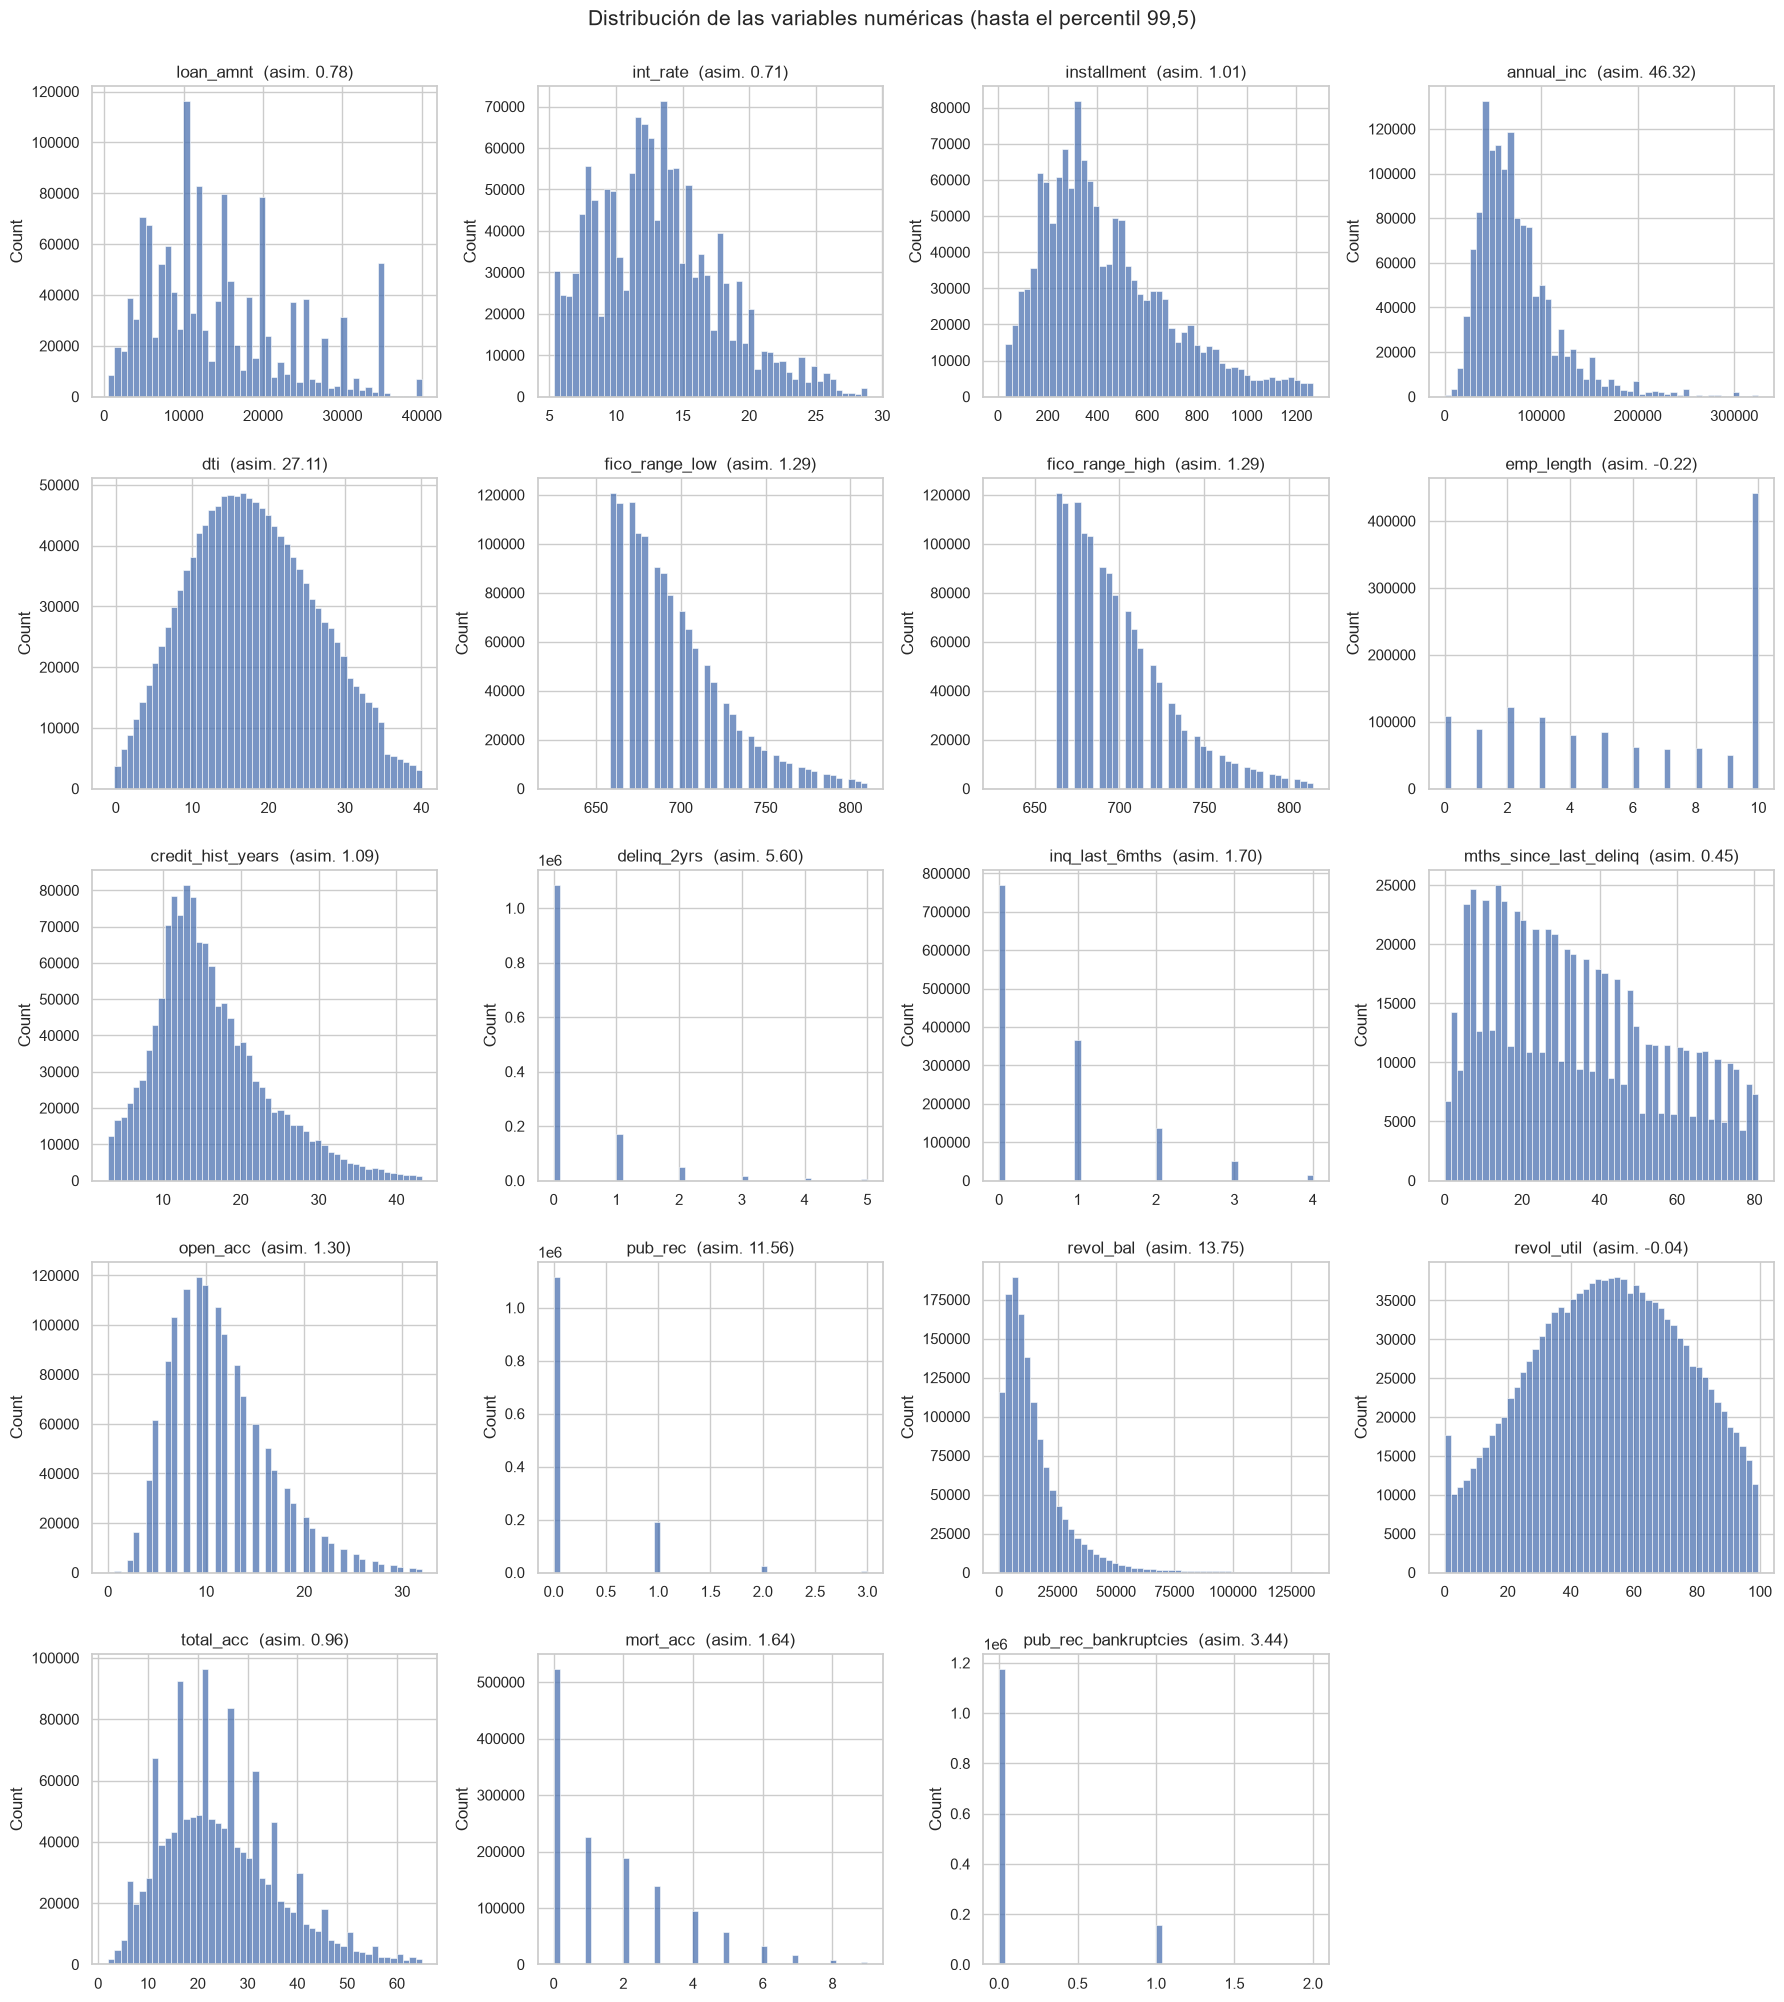

In [15]:
fig, axes = plt.subplots(5, 4, figsize=(18, 20))
for ax, c in zip(axes.flat, U.NUM_COLS):
    x = df[c].dropna()
    hi = x.quantile(0.995)
    sns.histplot(x[x <= hi], bins=50, ax=ax, color="#4C72B0")
    ax.set_title(f"{c}  (asim. {x.skew():.2f})")
    ax.set_xlabel("")
for ax in axes.flat[len(U.NUM_COLS):]:
    ax.remove()
fig.suptitle("Distribución de las variables numéricas (hasta el percentil 99,5)", y=1.0, fontsize=15)
plt.tight_layout()
plt.show()

Los histogramas evidencian el carácter institucional de varias variables. `loan_amnt` concentra la masa en montos redondos (10.000, 12.000, 15.000, 20.000 y 35.000 dólares) e `int_rate` presenta picos asociados a los subgrados de Lending Club. `fico_range_*` comienza abruptamente cerca de 660 puntos, el mínimo de aceptación de la plataforma durante la mayor parte del periodo: la distribución está truncada por la política de crédito y no representa a la población general de solicitantes. `emp_length` es claramente bimodal por la acumulación en la categoría abierta "10+ años", que reúne alrededor de un tercio de los casos. Por último, `dti` y `revol_util` son aproximadamente simétricas dentro del percentil 99,5, lo que indica que su asimetría global se debe a un grupo reducido de valores extremos y no a la forma del cuerpo de la distribución.

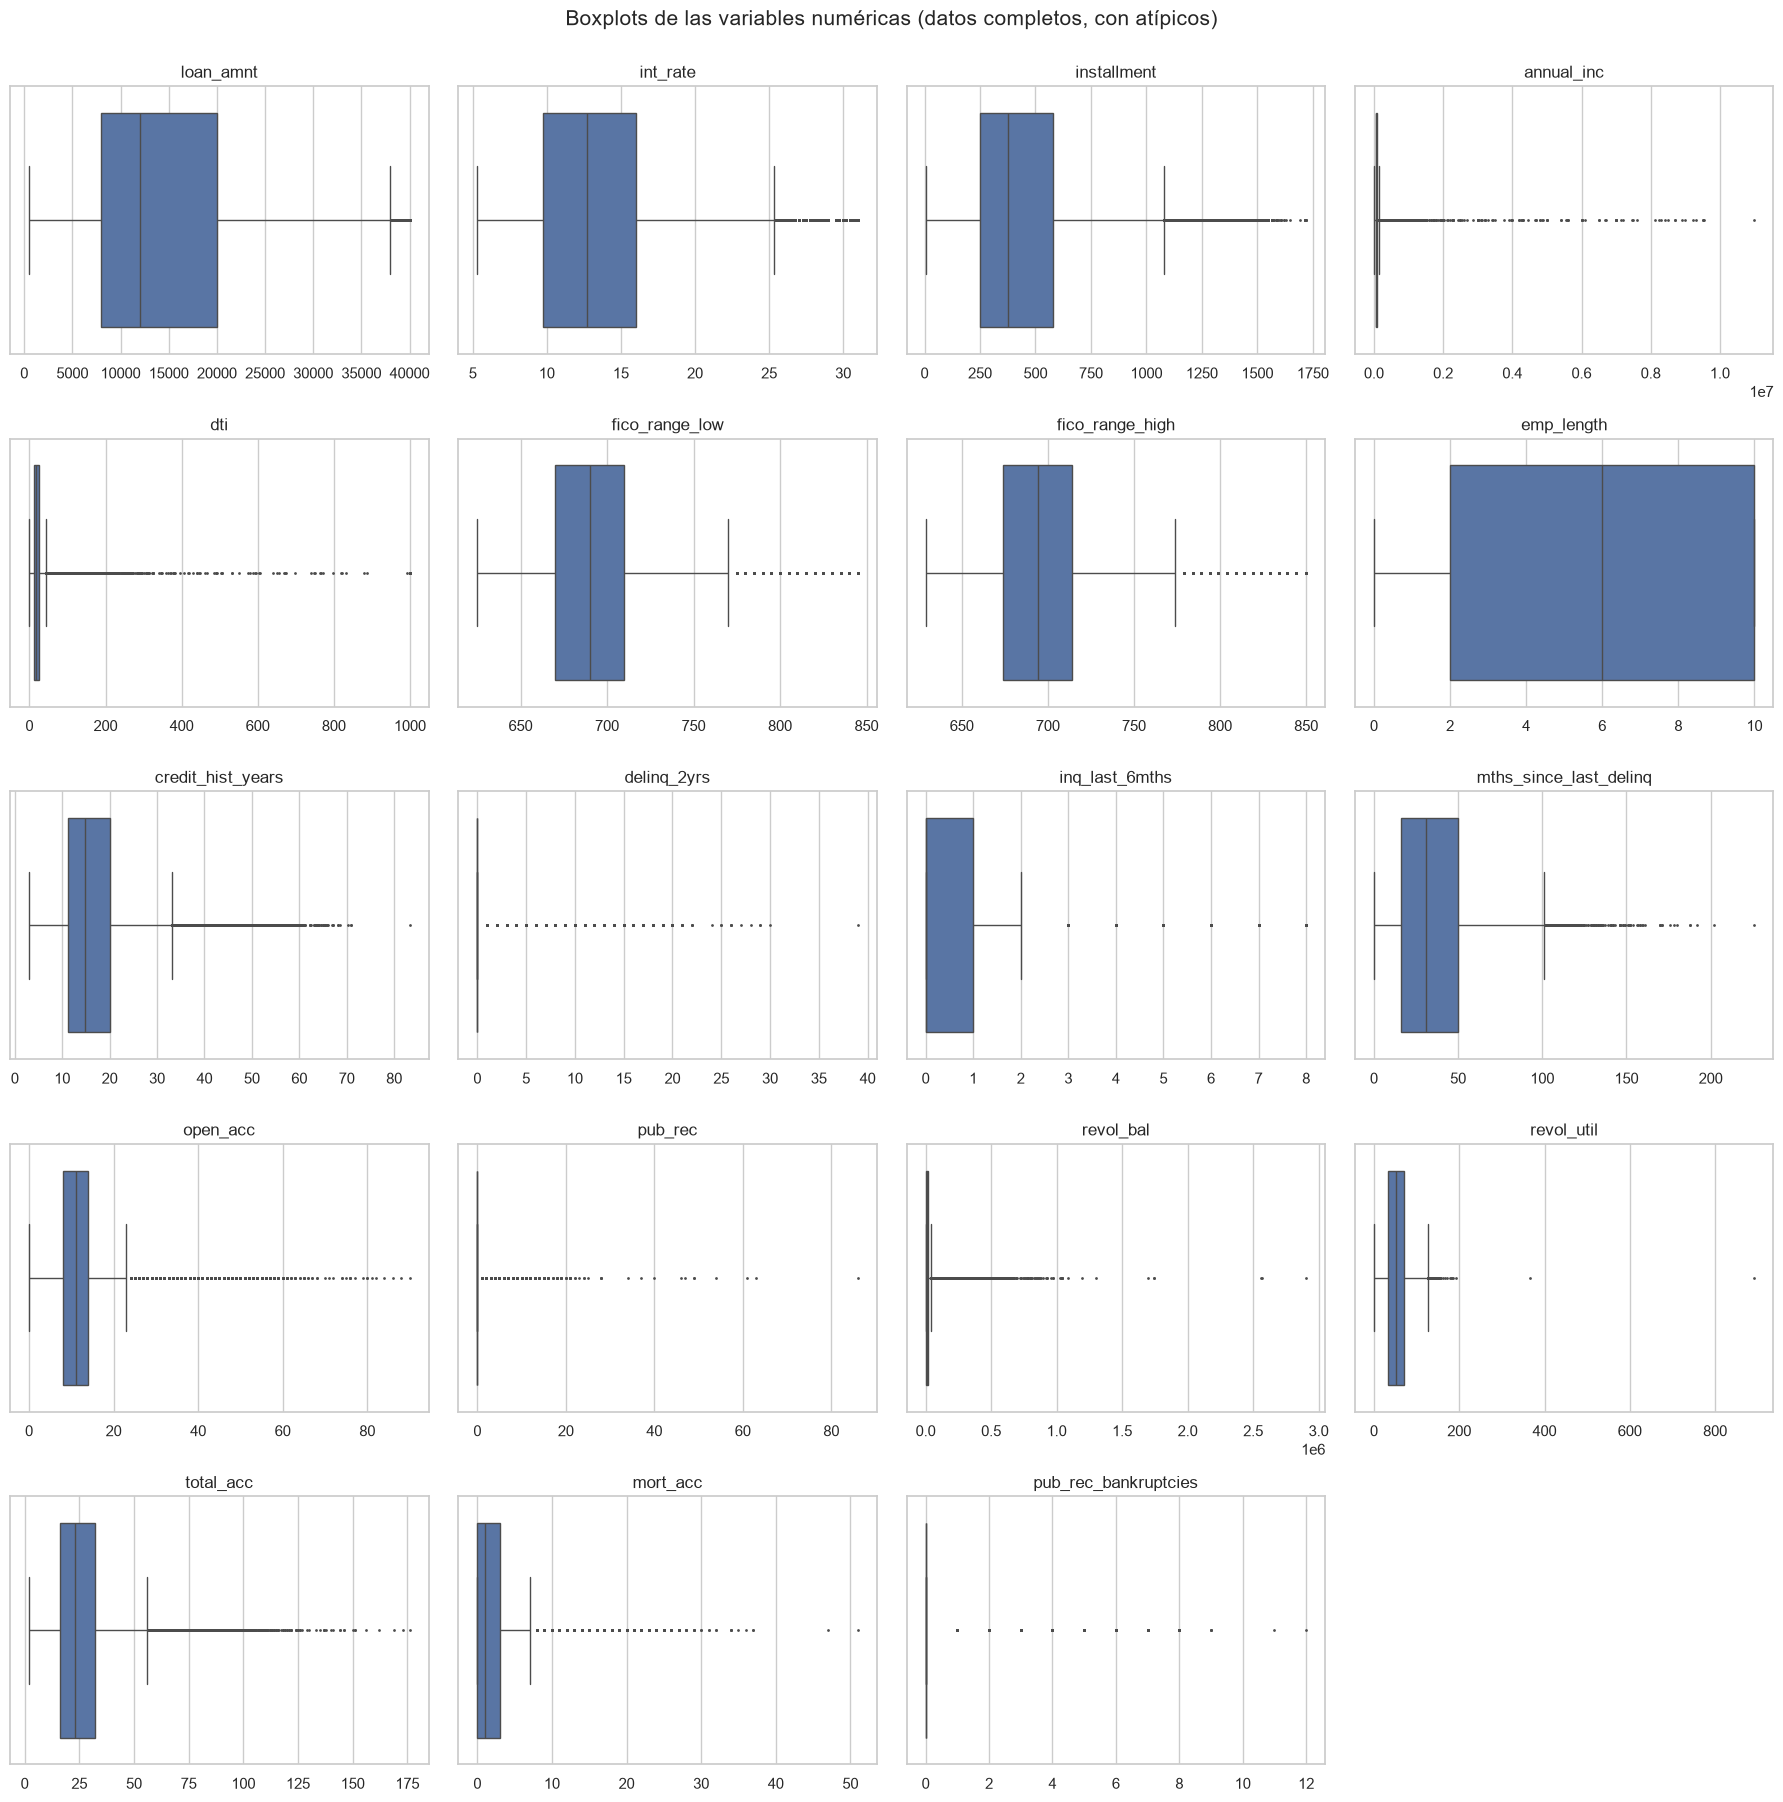

In [16]:
fig, axes = plt.subplots(5, 4, figsize=(18, 18))
for ax, c in zip(axes.flat, U.NUM_COLS):
    sns.boxplot(x=df[c].dropna(), ax=ax, color="#4C72B0", fliersize=1)
    ax.set_title(c)
    ax.set_xlabel("")
for ax in axes.flat[len(U.NUM_COLS):]:
    ax.remove()
fig.suptitle("Boxplots de las variables numéricas (datos completos, con atípicos)", y=1.0, fontsize=15)
plt.tight_layout()
plt.show()

Los diagramas de caja sobre la totalidad de los datos muestran la magnitud de esas colas. `annual_inc` alcanza 11 millones de dólares con una caja comprimida por debajo de 100 mil; `dti` y `revol_util` presentan valores aislados cercanos a 1000 y 900, y `revol_bal` llega a 2,9 millones. Aunque escasos, estos extremos dominarían la media y la varianza que estima el `StandardScaler`, y con ello el ajuste de los modelos lineales. Por ello se opta por recortar `dti` y `revol_util` a los percentiles 0,1 y 99,9 y por aplicar `log1p` a `annual_inc` y `revol_bal`. Los modelos basados en árboles son invariantes a estas transformaciones monótonas, de modo que la decisión no los perjudica.

**Normalidad.** Con $n \approx 1{,}3$ millones, cualquier prueba formal rechaza la normalidad ante desviaciones mínimas, y Shapiro-Wilk además solo es válida hasta $n = 5000$. Por eso se evalúa sobre todo la magnitud de la asimetría ($|g_1| < 0{,}5$ aproximadamente simétrica, $0{,}5$–$1$ moderada, $> 1$ severa). Como referencia se incluye:

* la prueba de D'Agostino-Pearson sobre todos los datos;
* Shapiro-Wilk sobre 5000 observaciones aleatorias, solo como ilustración.

Para cada variable se muestra también la asimetría tras aplicar `log1p` o Yeo-Johnson, para decidir si conviene transformarla.

In [17]:
rng = np.random.default_rng(U.SEED)
rows = []
for c in U.NUM_COLS:
    x = df[c].dropna().to_numpy(dtype=float)
    sw_p = stats.shapiro(rng.choice(x, 5000, replace=False)).pvalue
    dp_p = stats.normaltest(x).pvalue
    skew = stats.skew(x)
    skew_log = stats.skew(np.log1p(x)) if x.min() >= 0 else np.nan
    yj, _ = stats.yeojohnson(x)
    rows.append({"variable": c, "asimetría": skew, "asim. log1p": skew_log,
                 "asim. Yeo-Johnson": stats.skew(yj),
                 "p D'Agostino (n completo)": dp_p, "p Shapiro (n=5000)": sw_p})
norm = pd.DataFrame(rows).set_index("variable")
norm["clasificación"] = pd.cut(norm["asimetría"].abs(), [-1, 0.5, 1, np.inf],
                               labels=["≈ simétrica", "moderada", "severa"])
norm.sort_values("asimetría", key=abs, ascending=False)

,asimetría,asim. log1p,asim. Yeo-Johnson,p D'Agostino (n completo),p Shapiro (n=5000),clasificación
variable,,,,,,
annual_inc,46.318,-1.886,0.187,0.000,0.000,severa
dti,27.111,NaN,0.297,0.000,0.000,severa
revol_bal,13.750,-2.650,0.197,0.000,0.000,severa
pub_rec,11.556,2.345,1.763,0.000,0.000,severa
delinq_2yrs,5.604,2.331,1.559,0.000,0.000,severa
pub_rec_bankruptcies,3.441,2.493,2.272,0.000,0.000,severa
inq_last_6mths,1.696,0.814,0.401,0.000,0.000,severa
mort_acc,1.637,0.330,0.114,0.000,0.000,severa
open_acc,1.296,-0.133,0.001,0.000,0.000,severa


Como era previsible con $n \approx 1{,}3$ millones, ambas pruebas rechazan la normalidad en todas las variables ($p < 0{,}001$), incluso en aquellas casi simétricas como `revol_util` (asimetría de −0,04). La decisión, por tanto, se apoya en la magnitud del sesgo: trece de las diecinueve variables presentan asimetría severa. La transformación `log1p` reduce notablemente la de `annual_inc` (de 46,3 a −1,9) y la de `revol_bal` (de 13,8 a −2,7), mientras que Yeo-Johnson las lleva prácticamente a la simetría (0,19 y 0,20). Se prefiere `log1p` por su interpretabilidad y porque se reproduce de forma trivial en Spark. En los contadores discretos (`pub_rec`, `delinq_2yrs`), ninguna transformación corrige la asimetría, que obedece a la masa concentrada en cero; por ello se mantienen en su escala original.

### 1.2.2 Variables categóricas

Para cada variable se reportan la frecuencia absoluta y relativa de cada categoría y se marcan las categorías con menos del 1 % de las observaciones, candidatas a agruparse en `OTHER`.

In [18]:
from IPython.display import display

for c in U.CAT_COLS:
    vc = df[c].value_counts(dropna=False)
    t = pd.DataFrame({"n": vc, "%": 100 * vc / len(df)})
    t["< 1 %"] = np.where(t["%"] < 1, "sí", "")
    print(f"\n=== {c}: {df[c].nunique()} categorías, {df[c].isna().mean()*100:.2f}% nulos")
    display(t if len(t) <= 16 else t.head(16))


=== term: 2 categorías, 0.00% nulos


,n,%,< 1 %
term,,,
36 months,1020743,75.874,
60 months,324567,24.126,



=== grade: 7 categorías, 0.00% nulos


,n,%,< 1 %
grade,,,
B,392741,29.193,
C,381686,28.372,
A,235090,17.475,
D,200953,14.937,
E,93650,6.961,
F,32058,2.383,
G,9132,0.679,sí



=== home_ownership: 6 categorías, 0.00% nulos


...

,n,%,< 1 %
addr_state,,,
CA,196528,14.608,
TX,110169,8.189,
NY,109842,8.165,
FL,95606,7.107,
IL,51720,3.844,
NJ,48449,3.601,
PA,45522,3.384,
OH,43842,3.259,
GA,43376,3.224,



=== initial_list_status: 2 categorías, 0.00% nulos


,n,%,< 1 %
initial_list_status,,,
w,784010,58.277,
f,561300,41.723,



=== application_type: 2 categorías, 0.00% nulos


,n,%,< 1 %
application_type,,,
Individual,1319510,98.082,
Joint App,25800,1.918,


Las frecuencias revelan distribuciones muy concentradas: `debt_consolidation` y `credit_card` suman el 80 % de los propósitos, las solicitudes individuales representan el 98,1 % y las categorías `MORTGAGE` y `RENT` el 89,2 % de la tenencia de vivienda. Las categorías residuales `ANY`, `OTHER` y `NONE` de `home_ownership` reúnen apenas 478 préstamos y corresponden a códigos heredados de las primeras etapas de la plataforma, por lo que se agrupan en una sola clase.

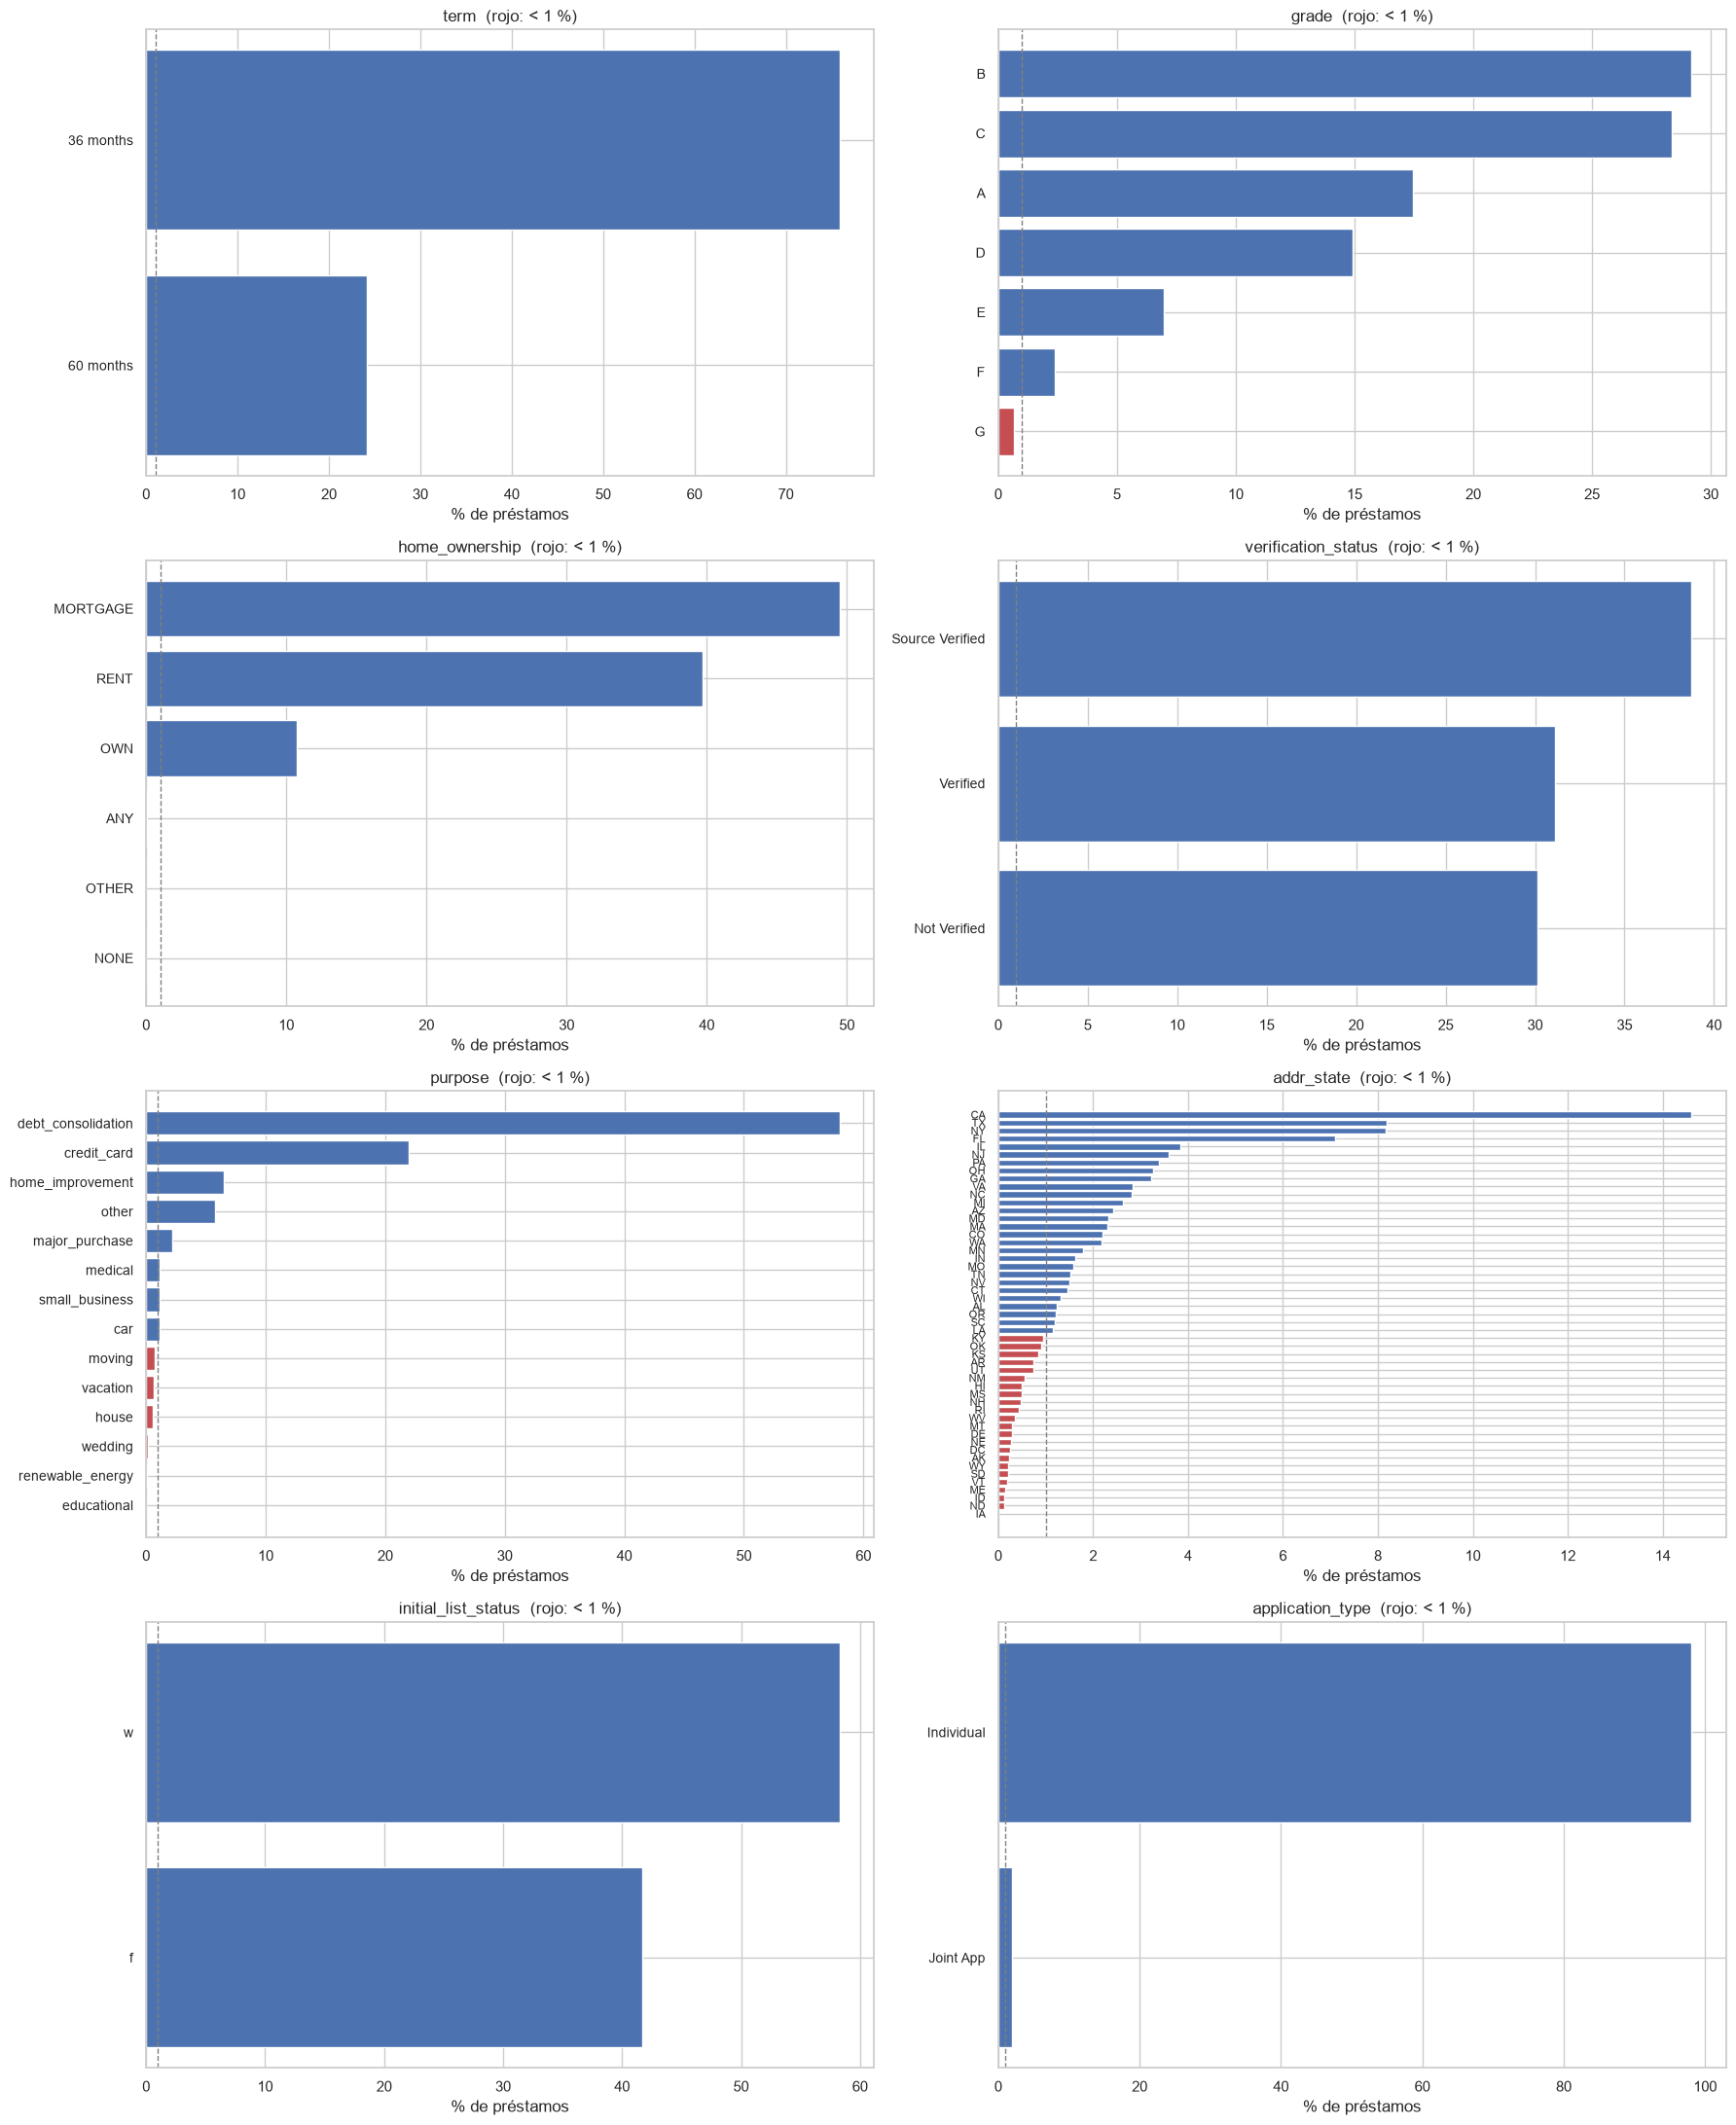

In [19]:
fig, axes = plt.subplots(4, 2, figsize=(18, 22))
for ax, c in zip(axes.flat, U.CAT_COLS):
    vc = df[c].value_counts(normalize=True).mul(100).sort_values()
    colors = np.where(vc < 1, "#C44E52", "#4C72B0")
    ax.barh(vc.index.astype(str), vc.values, color=colors)
    ax.axvline(1, ls="--", c="grey", lw=1)
    ax.set_title(f"{c}  (rojo: < 1 %)")
    ax.set_xlabel("% de préstamos")
    ax.tick_params(axis="y", labelsize=8 if len(vc) > 20 else 10)
plt.tight_layout()
plt.show()

Los gráficos ponen de manifiesto la cola larga de `purpose` y de `addr_state`: seis propósitos y veintitrés estados tienen menos del 1 % de los préstamos. En `purpose` las categorías raras se agrupan en `other`. En `addr_state`, en cambio, se conservan los 51 niveles, porque la agrupación mezclaría estados con tasas de default muy distintas (sección 1.3.2) y el costo de 51 columnas binarias es moderado frente a 1,08 millones de observaciones de entrenamiento.

In [20]:
rare = {c: df[c].value_counts(normalize=True).loc[lambda s: s < 0.01].index.tolist() for c in U.CAT_COLS}
{c: v for c, v in rare.items() if v}

{'grade': ['G'],
 'home_ownership': ['ANY', 'OTHER', 'NONE'],
 'purpose': ['moving',
  'vacation',
  'house',
  'wedding',
  'renewable_energy',
  'educational'],
 'addr_state': ['KY',
  'OK',
  'KS',
  'AR',
  'UT',
  'NM',
  'HI',
  'MS',
  'NH',
  'RI',
  'WV',
  'MT',
  'DE',
  'NE',
  'DC',
  'AK',
  'WY',
  'SD',
  'VT',
  'ME',
  'ID',
  'ND',
  'IA']}

La lista confirma las categorías minoritarias identificadas en los gráficos. El grado G (0,68 %) no se agrupa, pues tiene un significado ordinal y la mayor tasa de default del conjunto. De todos modos, `grade` se excluye finalmente del modelado por su redundancia con `int_rate` (sección 1.3.3).

### 1.2.3 Variable objetivo `default`

,clase,n,%
0,Fully Paid (0),1076751,80.037
1,Charged Off (1),268559,19.963


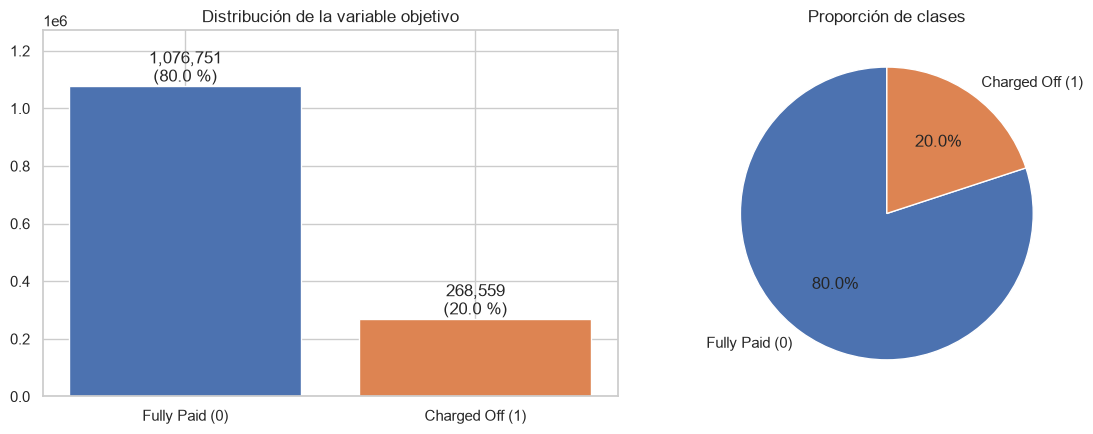

In [21]:
tc = df[U.TARGET].value_counts().sort_index()
target_tbl = pd.DataFrame({"clase": ["Fully Paid (0)", "Charged Off (1)"], "n": tc.values,
                           "%": 100 * tc.values / tc.sum()})
display(target_tbl)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(target_tbl["clase"], target_tbl["n"], color=[PALETTE[0], PALETTE[1]])
for i, (n, p) in enumerate(zip(target_tbl["n"], target_tbl["%"])):
    axes[0].text(i, n, f"{n:,}\n({p:.1f} %)", ha="center", va="bottom")
axes[0].set_ylim(0, target_tbl["n"].max() * 1.18)
axes[0].set_title("Distribución de la variable objetivo")
axes[1].pie(target_tbl["n"], labels=target_tbl["clase"], autopct="%1.1f%%",
            colors=[PALETTE[0], PALETTE[1]], startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Proporción de clases")
plt.tight_layout()
plt.show()

La variable objetivo presenta un desbalance moderado, con 19,96 % de préstamos en default (268.559 casos). No se trata de un desbalance extremo que obligue a remuestrear, pero sí basta para que la exactitud resulte engañosa (un clasificador trivial que nunca predijera default alcanzaría 80 %) y para que el umbral convencional de 0,5 produzca muy pocos positivos. En consecuencia, la partición y la validación cruzada se estratifican, la selección de modelos se basa en el ROC AUC y se reportan además el AUC-PR y el F1, métricas más sensibles al desempeño en la clase minoritaria.

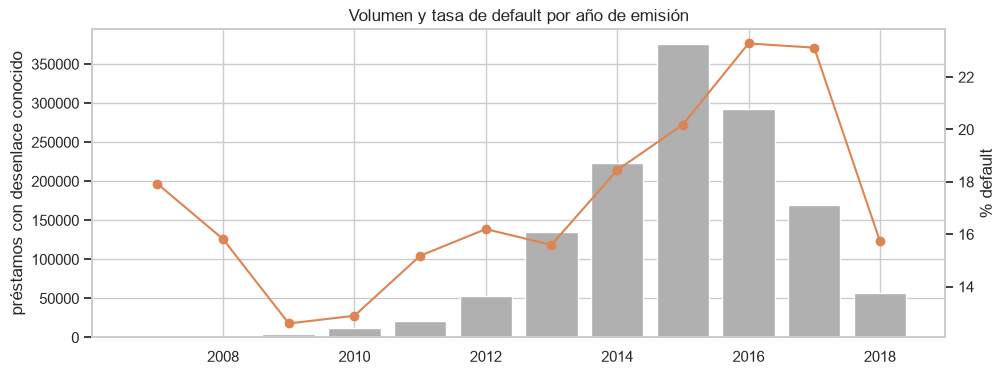

issue_d,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
size,251.000,"1,562.000","4,716.000","11,536.000","21,721.000","53,367.000","134,804.000","223,102.000","375,545.000","293,095.000","169,300.000","56,311.000"
pct_default,17.928,15.813,12.595,12.890,15.179,16.197,15.596,18.449,20.185,23.283,23.123,15.746


In [22]:
by_year = df.groupby(df["issue_d"].dt.year)[U.TARGET].agg(["size", "mean"])
fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(by_year.index, by_year["size"], color="#B0B0B0")
ax1.set_ylabel("préstamos con desenlace conocido")
ax2 = ax1.twinx()
ax2.plot(by_year.index, 100 * by_year["mean"], "o-", color=PALETTE[1])
ax2.set_ylabel("% default")
ax2.grid(False)
ax1.set_title("Volumen y tasa de default por año de emisión")
plt.show()
by_year.assign(pct_default=100 * by_year["mean"]).drop(columns="mean").T

La tasa de default no es estable en el tiempo. Desciende de 17,9 % en 2007 a 12,6 % en 2009, en un periodo de volumen reducido y criterios de aprobación más estrictos tras la crisis financiera, y crece de forma sostenida hasta 23,3 % en 2016, a medida que la plataforma amplía su oferta hacia segmentos de mayor riesgo. El descenso a 15,7 % en 2018 no refleja una mejora de la cartera, sino un sesgo de selección por censura. El archivo termina en el cuarto trimestre de 2018, de modo que de las emisiones recientes solo se observan los préstamos que ya concluyeron: los prepagados anticipadamente y los que cayeron en default temprano. Por esta razón `issue_d` no se emplea como predictor. Cabe advertir además que un modelo entrenado con una partición aleatoria mezcla cohortes, y su desempeño podría deteriorarse en una validación temporal.

## 1.3 Análisis bidimensional

### 1.3.1 Variables numéricas frente a `default`

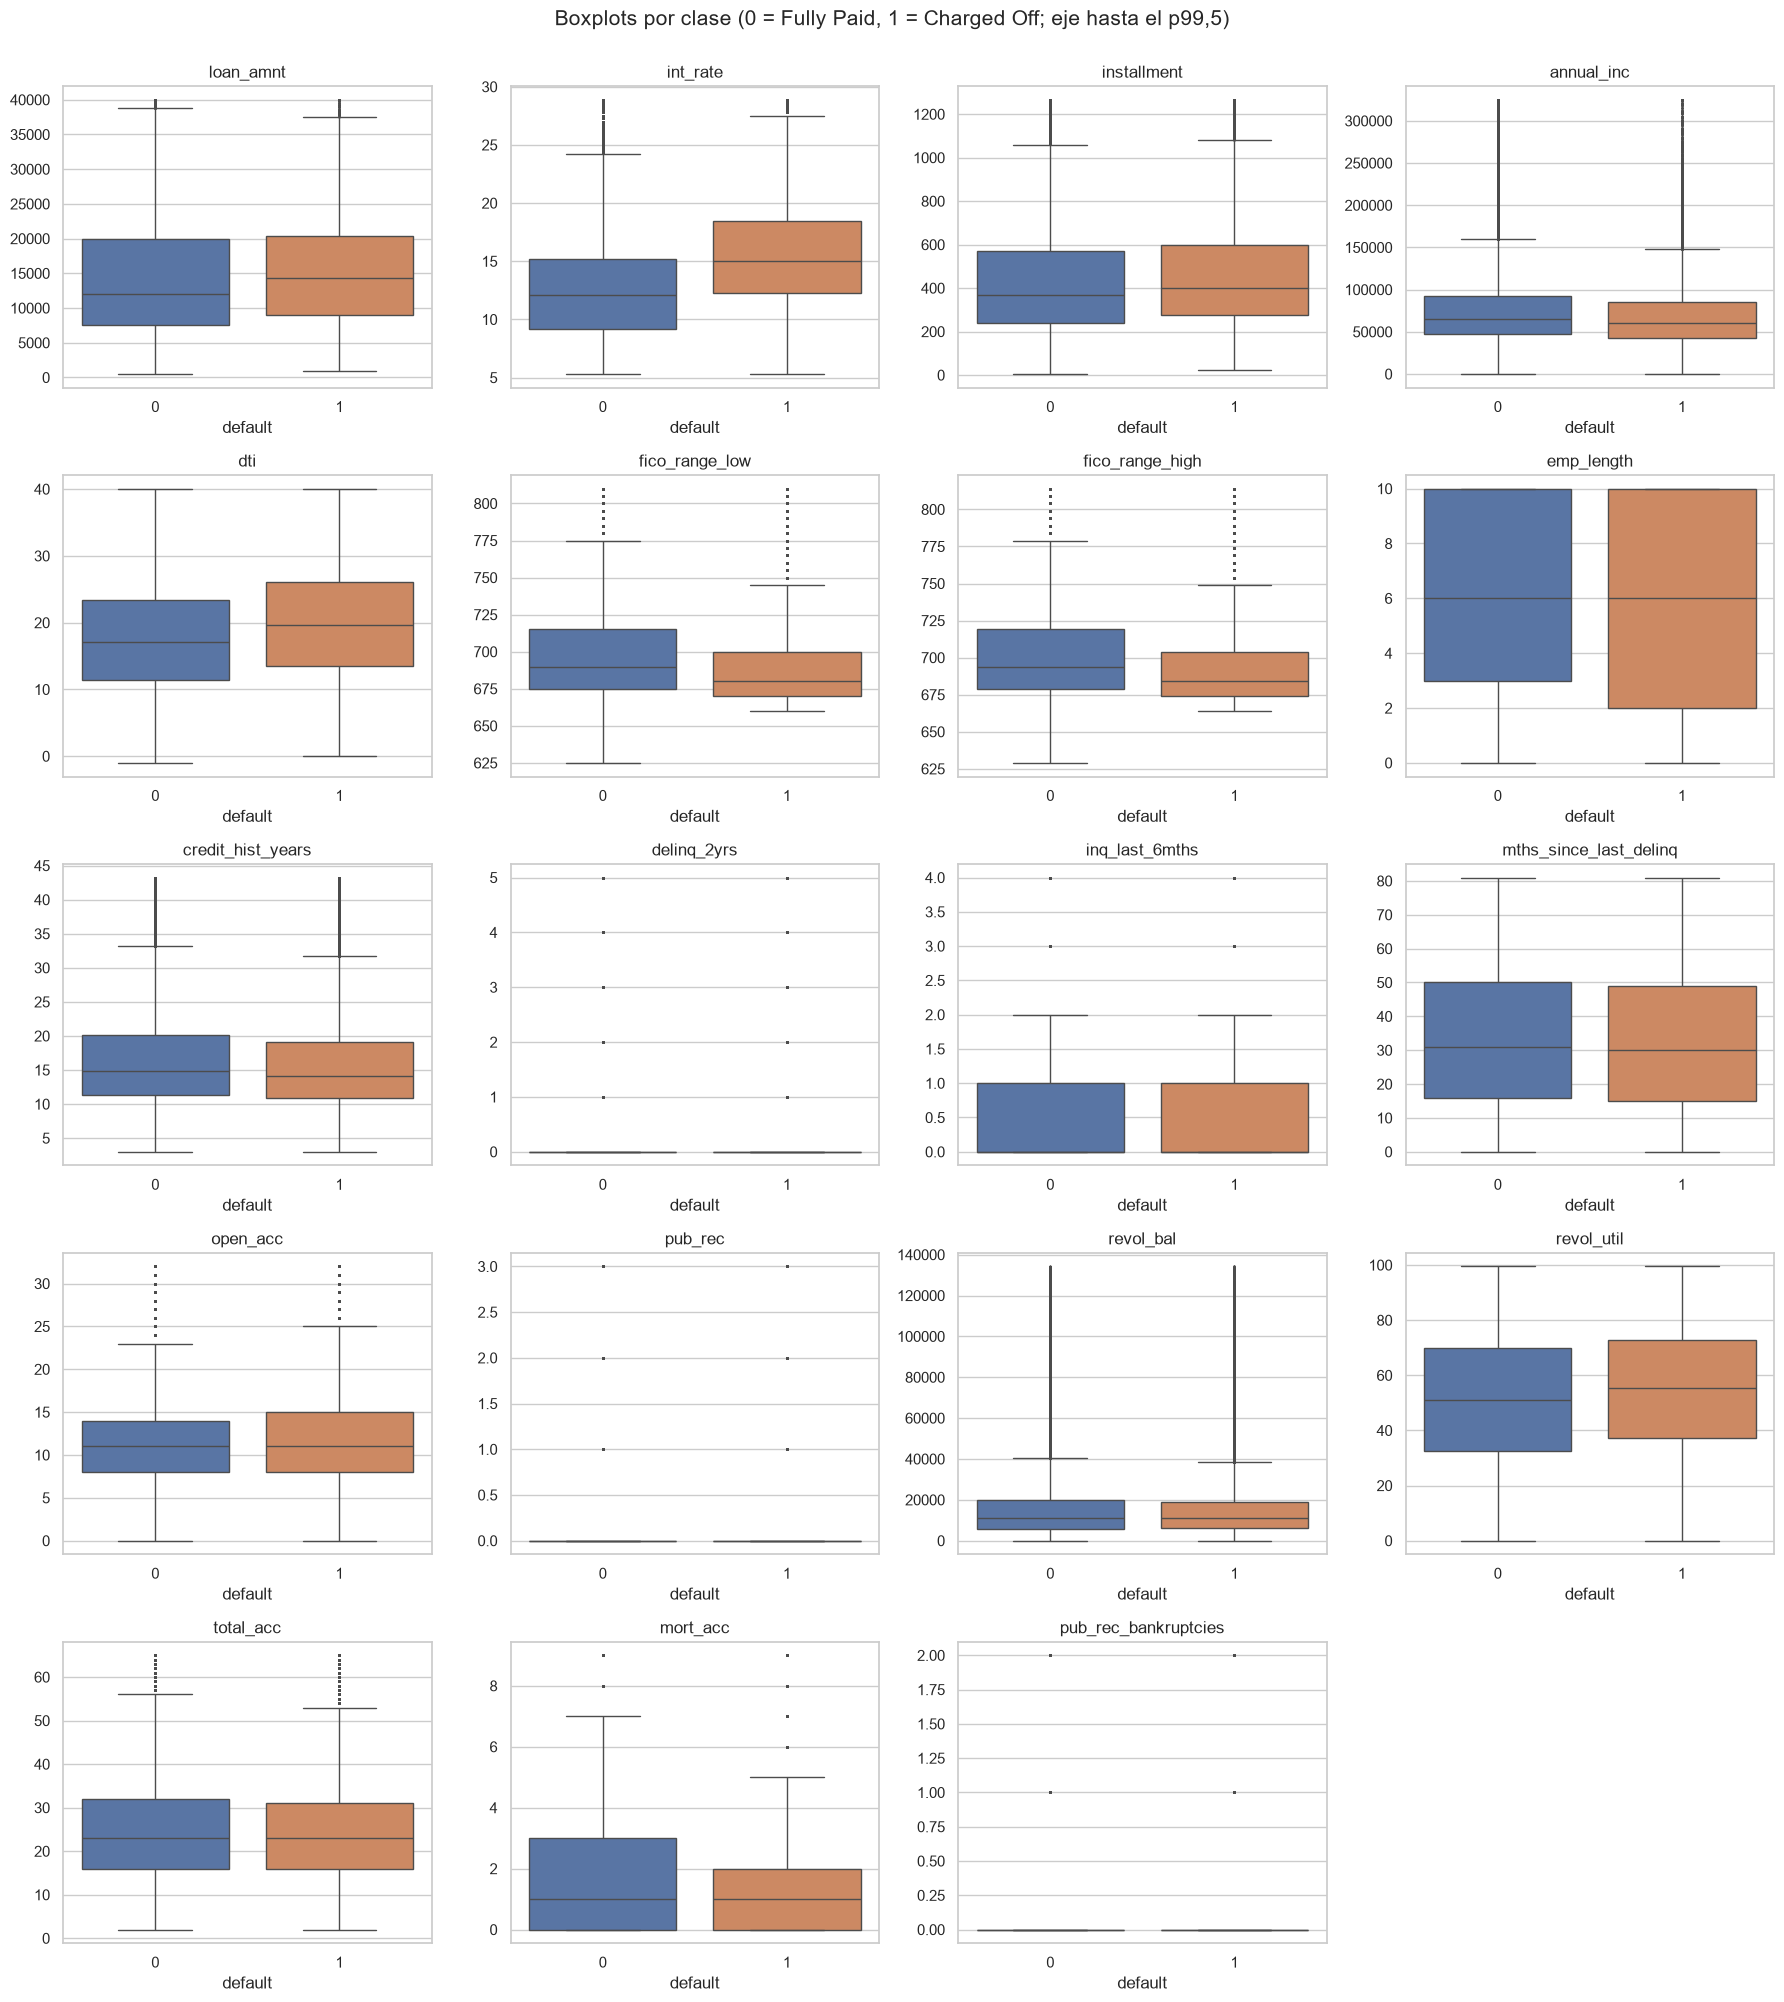

In [23]:
fig, axes = plt.subplots(5, 4, figsize=(18, 20))
for ax, c in zip(axes.flat, U.NUM_COLS):
    hi = df[c].quantile(0.995)
    sub = df.loc[df[c] <= hi, [c, U.TARGET]]
    sns.boxplot(data=sub, x=U.TARGET, y=c, ax=ax, hue=U.TARGET, palette=PALETTE, legend=False, fliersize=0.5)
    ax.set_title(c)
    ax.set_xlabel("default")
    ax.set_ylabel("")
for ax in axes.flat[len(U.NUM_COLS):]:
    ax.remove()
fig.suptitle("Boxplots por clase (0 = Fully Paid, 1 = Charged Off; eje hasta el p99,5)", y=1.0, fontsize=15)
plt.tight_layout()
plt.show()

La comparación por clase muestra que la variable con mayor separación es `int_rate`: la mediana de los préstamos en default (15,05 %) se sitúa cerca del tercer cuartil de los pagados. En `fico_range_high` la caja de los defaults se desplaza hacia abajo y queda truncada en el mínimo de aceptación, y en `dti` y `revol_util` se desplaza moderadamente hacia arriba. En el resto de las variables las cajas se superponen casi por completo, lo que anticipa efectos individuales pequeños.

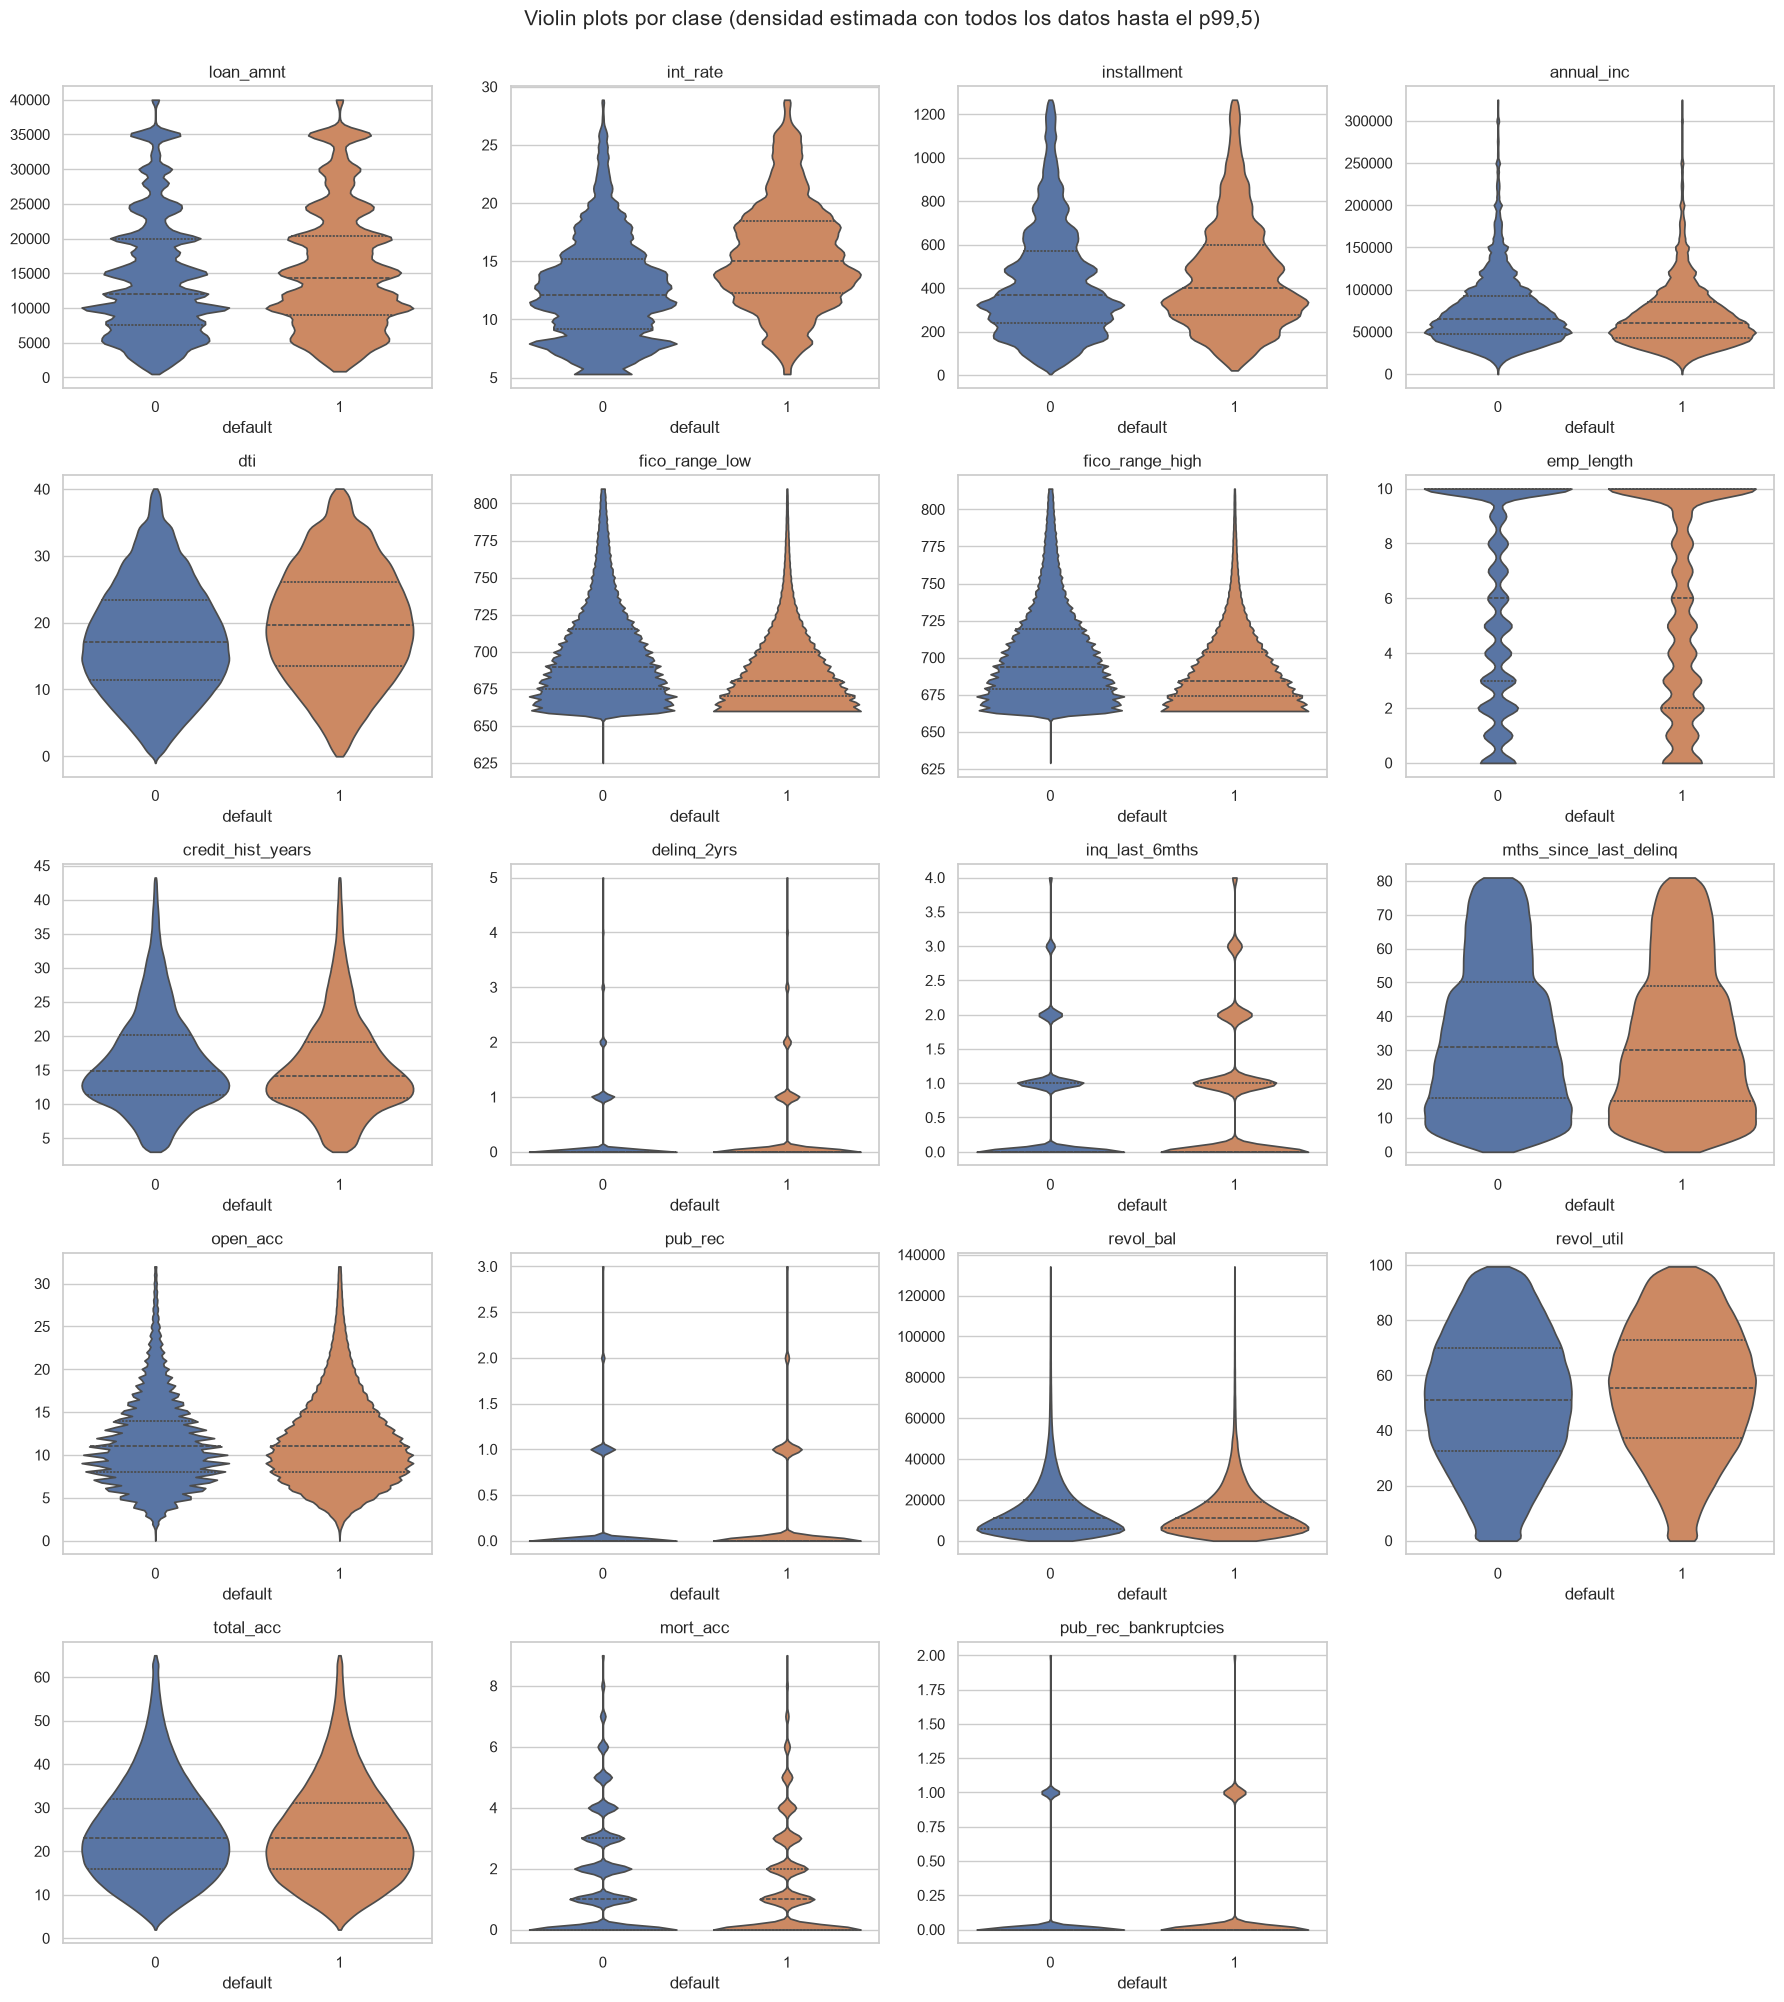

In [24]:
fig, axes = plt.subplots(5, 4, figsize=(18, 20))
for ax, c in zip(axes.flat, U.NUM_COLS):
    hi = df[c].quantile(0.995)
    sub = df.loc[df[c] <= hi, [c, U.TARGET]]
    sns.violinplot(data=sub, x=U.TARGET, y=c, ax=ax, hue=U.TARGET, palette=PALETTE, legend=False, cut=0, inner="quartile")
    ax.set_title(c)
    ax.set_xlabel("default")
    ax.set_ylabel("")
for ax in axes.flat[len(U.NUM_COLS):]:
    ax.remove()
fig.suptitle("Violin plots por clase (densidad estimada con todos los datos hasta el p99,5)", y=1.0, fontsize=15)
plt.tight_layout()
plt.show()

Los violines confirman que las diferencias entre clases son de posición y no de forma. Las densidades de ambos grupos comparten la misma estructura multimodal en `loan_amnt` y `emp_length`, y solo en `int_rate` se aprecia un desplazamiento sustancial de toda la masa de probabilidad. Esta superposición generalizada indica que ningún predictor aislado separa adecuadamente las clases: se trata de un problema de discriminación intrínsecamente difícil, en el que un AUC cercano a 0,70 constituye un resultado razonable.

**Pruebas de diferencia entre clases.** Ninguna variable es normal (sección 1.2.1), así que la prueba principal es **Mann-Whitney U**. Se reporta también la **t de Welch**, que es robusta a varianzas distintas y válida asintóticamente con este $n$ por el teorema central del límite. Como tamaños de efecto se incluyen:

* la **correlación biserial por rangos**, $r_{rb} = 1 - 2U/(n_0 n_1)$;
* la **correlación punto-biserial** $r_{pb}$ con `default`.

Con más de un millón de observaciones casi cualquier diferencia resulta significativa ($p < 0{,}05$), por lo que el orden de relevancia se establece por el tamaño del efecto y no por el valor p.

In [25]:
rows = []
for c in U.NUM_COLS:
    sub = df[[c, U.TARGET]].dropna()
    x0 = sub.loc[sub[U.TARGET] == 0, c].to_numpy(float)
    x1 = sub.loc[sub[U.TARGET] == 1, c].to_numpy(float)
    mw = stats.mannwhitneyu(x1, x0, alternative="two-sided")
    tt = stats.ttest_ind(x1, x0, equal_var=False)
    rpb = stats.pointbiserialr(sub[U.TARGET], sub[c])
    rows.append({
        "variable": c, "media Fully Paid": x0.mean(), "media Charged Off": x1.mean(),
        "Δ medias (1−0)": x1.mean() - x0.mean(), "mediana 0": np.median(x0), "mediana 1": np.median(x1),
        "p Welch t": tt.pvalue, "p Mann-Whitney": mw.pvalue,
        "r rango-biserial": 1 - 2 * (len(x0) * len(x1) - mw.statistic) / (len(x0) * len(x1)),
        "r punto-biserial": rpb.statistic,
    })
biv_num = pd.DataFrame(rows).set_index("variable").sort_values("r punto-biserial", key=abs, ascending=False)
with pd.option_context("display.float_format", lambda v: f"{v:,.4g}"):
    display(biv_num)

,media Fully Paid,media Charged Off,Δ medias (1−0),mediana 0,mediana 1,p Welch t,p Mann-Whitney,r rango-biserial,r punto-biserial
variable,,,,,,,,,
int_rate,12.62,15.71,3.087,12.23,15.05,0,0,0.367,0.2588
fico_range_low,698.3,687.9,-10.41,690,680,0,0,-0.1868,-0.1307
fico_range_high,702.3,691.9,-10.41,694,684,0,0,-0.1868,-0.1307
dti,17.81,20.17,2.36,17.11,19.76,0,0,0.1542,0.08451
mort_acc,1.746,1.371,-0.3754,1,1,0,0,-0.1118,-0.07529
loan_amnt,1.413e+04,1.557e+04,"1,431",1.2e+04,1.435e+04,0,0,0.1022,0.0656
inq_last_6mths,0.6244,0.778,0.1536,0,0,0,0,0.08351,0.06545
revol_util,51.07,54.76,3.684,51.3,55.5,0,0,0.08591,0.06005
installment,431.3,465.1,33.82,368.3,402.8,0,0,0.08628,0.0517


Todas las diferencias resultan estadísticamente significativas (el mayor valor p es del orden de $10^{-23}$), lo que ilustra la trivialidad de la significancia con muestras de este tamaño. El tamaño del efecto, en cambio, ordena con claridad las variables. `int_rate` domina con amplitud (correlación biserial por rangos de 0,37 y punto-biserial de 0,26), seguida de `fico_range` (−0,19 y −0,13) y de `dti` (0,15 y 0,08). `mort_acc`, `loan_amnt`, `inq_last_6mths`, `revol_util`, `installment` y `annual_inc` forman un segundo grupo con efectos pequeños ($|r_{pb}|$ entre 0,04 y 0,08), y el resto tiene efectos despreciables ($|r_{pb}| < 0{,}035$). La coincidencia de signo y orden entre la correlación biserial por rangos, que no supone normalidad, y la punto-biserial indica que las conclusiones son robustas al supuesto distribucional.

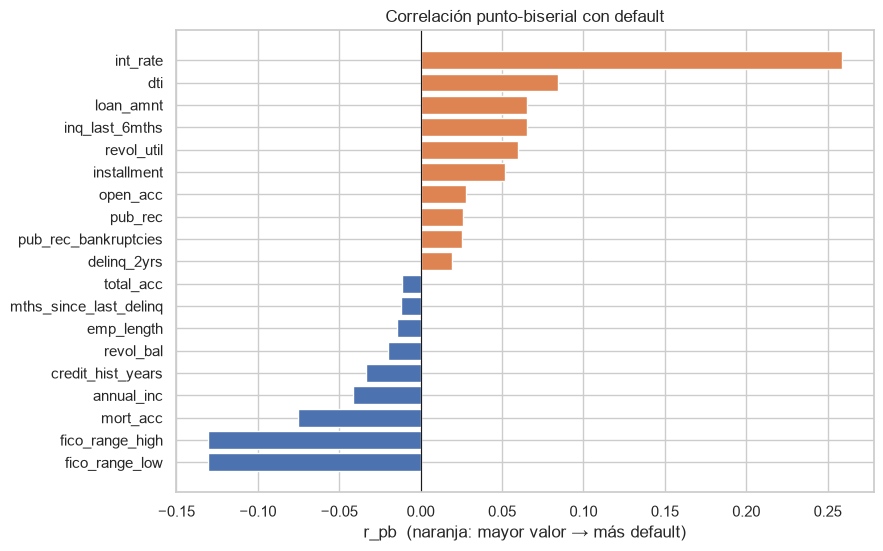

In [26]:
fig, ax = plt.subplots(figsize=(9, 6))
s = biv_num["r punto-biserial"].sort_values()
ax.barh(s.index, s.values, color=np.where(s > 0, PALETTE[1], PALETTE[0]))
ax.axvline(0, c="k", lw=0.8)
ax.set_title("Correlación punto-biserial con default")
ax.set_xlabel("r_pb  (naranja: mayor valor → más default)")
plt.show()

El gráfico sintetiza la dirección de los efectos. Un mayor costo del crédito, mayor endeudamiento, más consultas recientes, una mayor utilización del cupo revolvente y un monto solicitado más alto se asocian con más default. Un mejor puntaje FICO, más créditos hipotecarios, un ingreso mayor y un historial crediticio más largo actúan como factores protectores. Estos signos son coherentes con la teoría del riesgo de crédito, lo que respalda la validez de los datos.

### 1.3.2 Variables categóricas frente a `default`

Para cada variable se calculan la tasa de default por categoría (tabla de contingencia normalizada), la prueba chi-cuadrado de independencia y la V de Cramér como tamaño del efecto.

In [27]:
rows = []
for c in U.CAT_COLS:
    ct = pd.crosstab(df[c], df[U.TARGET])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    rows.append({"variable": c, "categorías": ct.shape[0], "chi2": chi2, "gl": dof, "p-value": p,
                 "V de Cramér": U.cramers_v(df[c], df[U.TARGET])})
biv_cat = pd.DataFrame(rows).set_index("variable").sort_values("V de Cramér", ascending=False)
with pd.option_context("display.float_format", lambda v: f"{v:,.4g}"):
    display(biv_cat)

,categorías,chi2,gl,p-value,V de Cramér
variable,,,,,
grade,7,9.228e+04,6,0,0.2619
term,2,4.172e+04,1,0,0.1761
verification_status,3,1.139e+04,2,0,0.09199
home_ownership,6,"6,743",5,0,0.07077
purpose,14,"4,144",13,0,0.05541
addr_state,51,"3,404",50,0,0.04993
application_type,2,352.1,1,1.478e-78,0.01616
initial_list_status,2,71.32,1,3.041e-17,0.007232


La prueba chi-cuadrado rechaza la independencia en las ocho variables, pero la V de Cramér distingue tres niveles de asociación: fuerte en `grade` (0,26) y moderada en `term` (0,18); débil en `verification_status`, `home_ownership`, `purpose` y `addr_state` (entre 0,05 y 0,09), y prácticamente nula en `application_type` e `initial_list_status` (menos de 0,02). En esta última, pese a un valor p de $3 \times 10^{-17}$, la diferencia entre las tasas de default de sus dos categorías es inferior a un punto porcentual, sin relevancia práctica alguna.

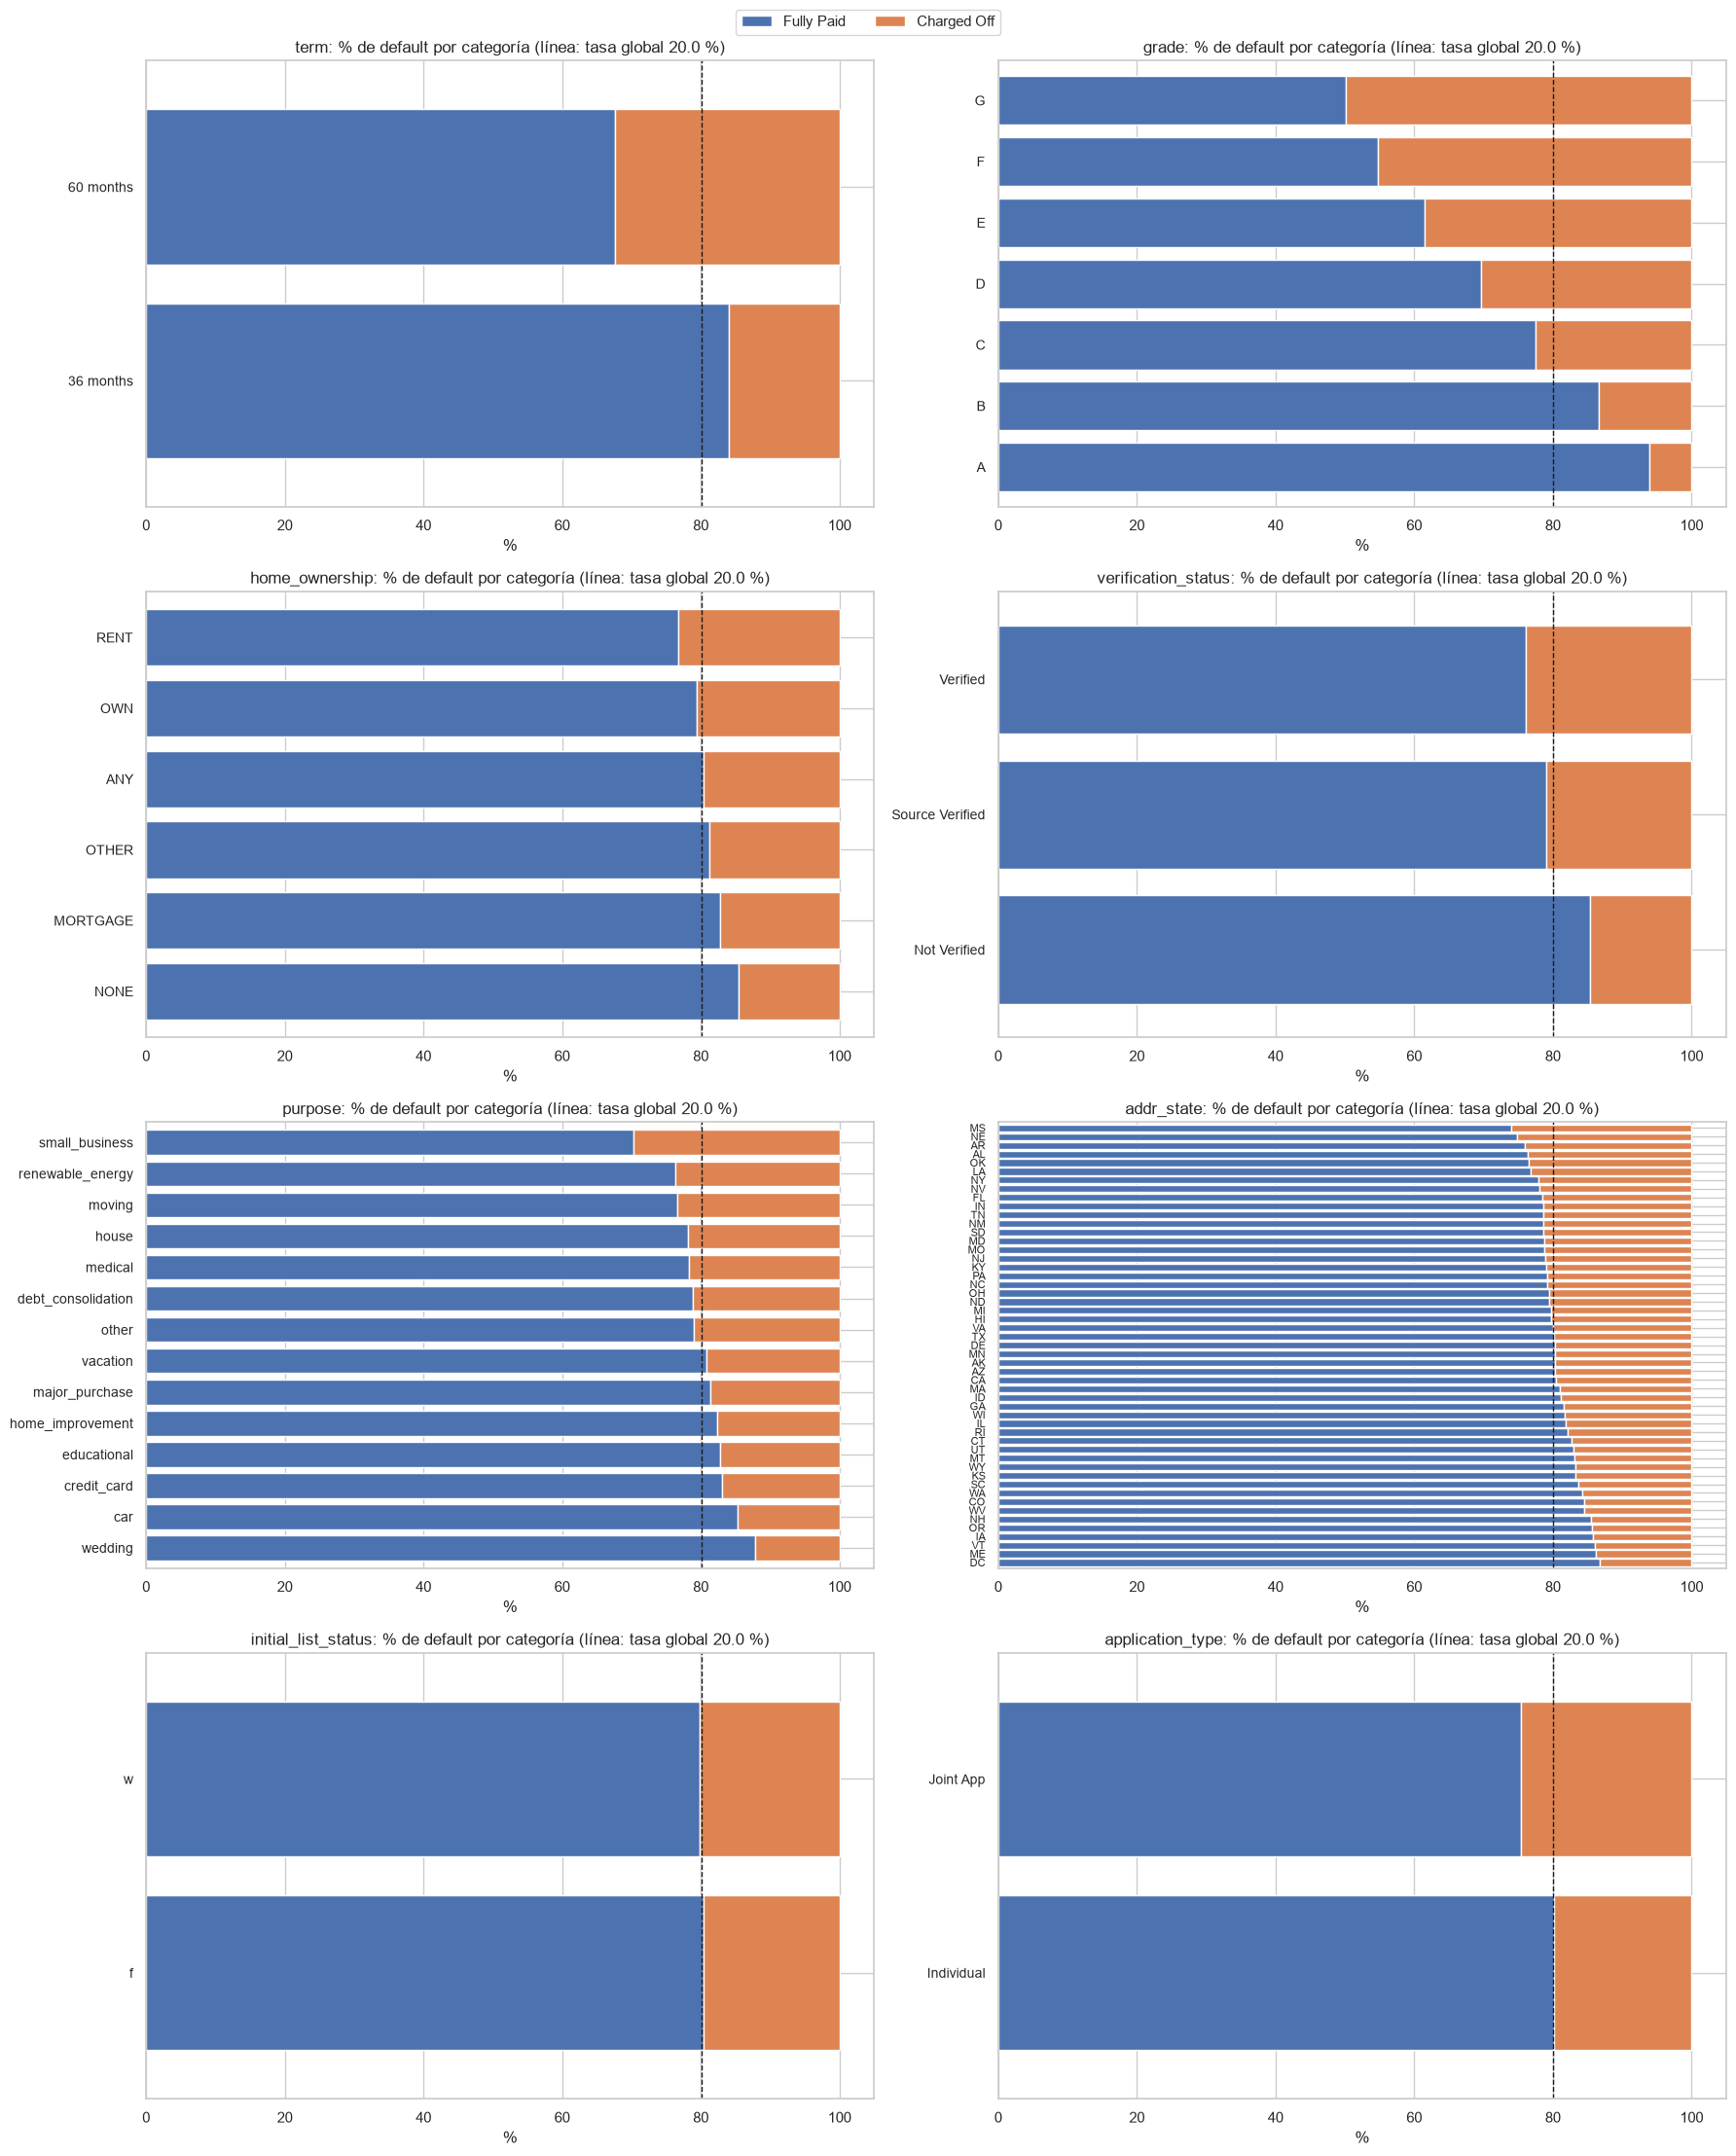

In [28]:
base_rate = df[U.TARGET].mean() * 100
fig, axes = plt.subplots(4, 2, figsize=(18, 22))
for ax, c in zip(axes.flat, U.CAT_COLS):
    ct = pd.crosstab(df[c], df[U.TARGET], normalize="index").mul(100).sort_values(1)
    ct.plot.barh(stacked=True, ax=ax, color=[PALETTE[0], PALETTE[1]], width=0.8, legend=False)
    ax.axvline(100 - base_rate, c="k", ls="--", lw=1)
    ax.set_title(f"{c}: % de default por categoría (línea: tasa global {base_rate:.1f} %)")
    ax.set_xlabel("%")
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=8 if ct.shape[0] > 20 else 10)
handles, _ = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, ["Fully Paid", "Charged Off"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.01))
plt.tight_layout()
plt.show()

Las barras apiladas muestran el gradiente de riesgo más nítido del conjunto: la tasa de default crece de forma monótona desde cerca del 6 % en el grado A hasta el 50 % en el G, y en los préstamos a 60 meses es 1,6 veces la tasa global. Resulta contraintuitivo que los préstamos con ingresos verificados presenten más default (23,9 %) que los no verificados. La explicación más plausible es un sesgo de selección: la plataforma exige la verificación precisamente a los solicitantes de mayor riesgo o de mayor monto. En `purpose` destaca `small_business` (29,7 %), muy por encima del promedio, mientras que `wedding` y `car` quedan por debajo. En `addr_state` las tasas oscilan aproximadamente entre 13 % y 26 %, con Misisipi, Nebraska y Arkansas en el extremo superior.

In [29]:
# Categorías con al menos 1000 préstamos y tasa de default más alta
rows = []
for c in U.CAT_COLS:
    g = df.groupby(c, observed=True)[U.TARGET].agg(["size", "mean"])
    g = g[g["size"] >= 1000]
    for cat, r in g.iterrows():
        rows.append({"variable": c, "categoría": cat, "n": int(r["size"]), "% default": 100 * r["mean"],
                     "riesgo relativo": r["mean"] / (base_rate / 100)})
risk = pd.DataFrame(rows).sort_values("% default", ascending=False)
risk.head(15)

,variable,categoría,n,% default,riesgo relativo
8,grade,G,9132,49.934,2.501
7,grade,F,32058,45.202,2.264
6,grade,E,93650,38.478,1.928
1,term,60 months,324567,32.445,1.625
5,grade,D,200953,30.382,1.522
24,purpose,small_business,15416,29.709,1.488
51,addr_state,MS,6588,26.078,1.306
55,addr_state,NE,3586,25.181,1.261
80,application_type,Joint App,25800,24.589,1.232
29,addr_state,AR,10047,24.087,1.207


Restringiendo el análisis a categorías con al menos mil préstamos, las de mayor riesgo relativo son los grados G, F y E (2,5, 2,3 y 1,9 veces la tasa global), el plazo de 60 meses (1,6), el grado D (1,5) y el propósito `small_business` (1,5). Que los primeros lugares correspondan a `grade` y `term` confirma que la evaluación de riesgo de la propia plataforma concentra buena parte de la información predictiva disponible.

### 1.3.3 Relaciones entre variables independientes (multicolinealidad)

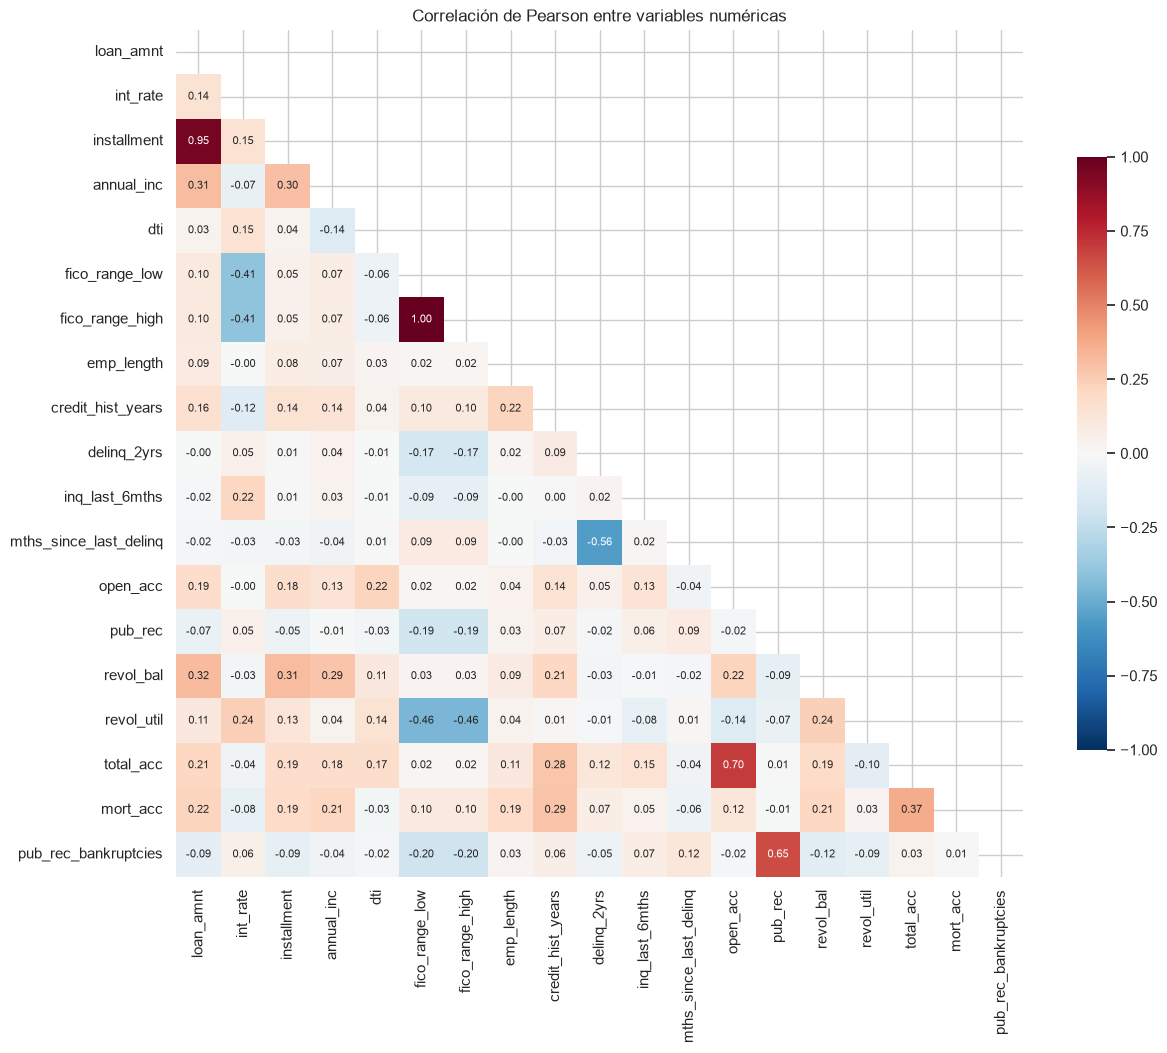

In [30]:
corr = df[U.NUM_COLS].corr(method="pearson")
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 8}, square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlación de Pearson entre variables numéricas")
plt.show()

La matriz de correlación de Pearson muestra que la mayoría de los pares de variables numéricas presenta correlaciones bajas ($|r| < 0{,}3$), lo que indica que aportan información en gran medida complementaria. Las excepciones se concentran en pares con una relación estructural evidente, que se detallan en la tabla siguiente.

In [31]:
pairs = (corr.where(~mask).stack().rename("r").reset_index()
         .rename(columns={"level_0": "var_1", "level_1": "var_2"}))
pairs["|r|"] = pairs["r"].abs()
pairs.sort_values("|r|", ascending=False).head(10)

,var_1,var_2,r,|r|
20,fico_range_high,fico_range_low,1.000,1.000
1,installment,loan_amnt,0.953,0.953
132,total_acc,open_acc,0.701,0.701
166,pub_rec_bankruptcies,pub_rec,0.650,0.650
64,mths_since_last_delinq,delinq_2yrs,-0.556,0.556
110,revol_util,fico_range_low,-0.460,0.460
111,revol_util,fico_range_high,-0.460,0.460
11,fico_range_low,int_rate,-0.405,0.405
16,fico_range_high,int_rate,-0.405,0.405
152,mort_acc,total_acc,0.368,0.368


Los dos primeros pares son redundancias casi perfectas de origen mecánico: `fico_range_low` y `fico_range_high` difieren en una constante de cuatro puntos ($r = 1{,}00$), e `installment` es una función determinista de `loan_amnt`, `int_rate` y `term` ($r = 0{,}95$). Por ello se conserva una sola variable de cada par (`fico_range_high` y `loan_amnt`). Las correlaciones entre `total_acc` y `open_acc` (0,70) y entre `pub_rec` y `pub_rec_bankruptcies` (0,65) rozan el umbral de multicolinealidad, pero cada variable aporta un matiz distinto (cuentas históricas frente a vigentes; registros públicos en general frente a quiebras). Por eso se mantienen, y la regularización L2 de los modelos lineales controla la posible inestabilidad de los coeficientes.

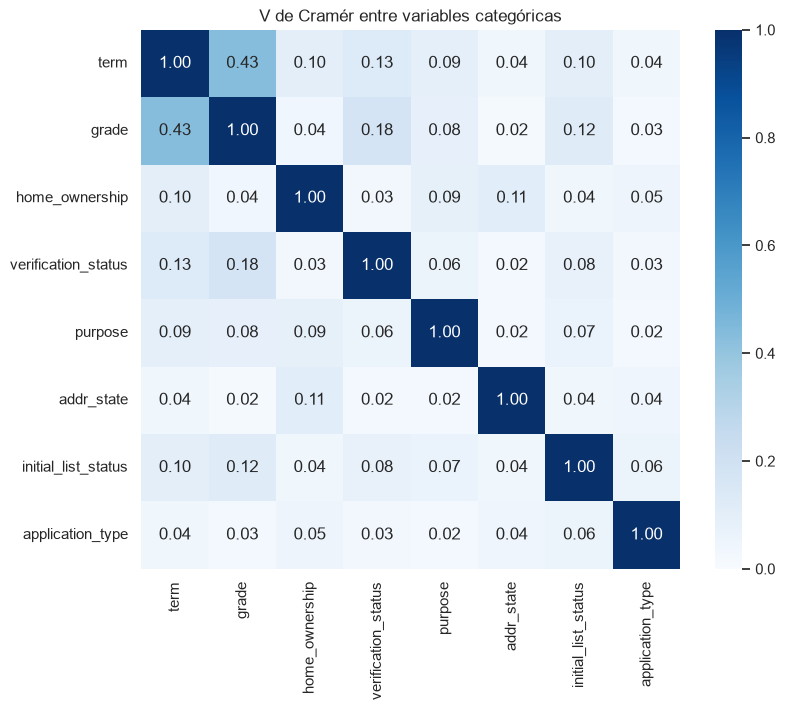

In [32]:
cv = pd.DataFrame(np.eye(len(U.CAT_COLS)), index=U.CAT_COLS, columns=U.CAT_COLS)
for i, a in enumerate(U.CAT_COLS):
    for b in U.CAT_COLS[i + 1:]:
        cv.loc[a, b] = cv.loc[b, a] = U.cramers_v(df[a], df[b])
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cv, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, square=True, ax=ax)
ax.set_title("V de Cramér entre variables categóricas")
plt.show()

Entre las variables categóricas, la única asociación apreciable es la de `term` con `grade` ($V = 0{,}43$): los préstamos a 60 meses se concentran en los grados de menor calidad. El resto de los pares presenta valores de V inferiores a 0,2, de modo que no existe una redundancia que justifique excluir variables categóricas por este motivo.

**Asociación entre variables numéricas y categóricas.** El enunciado menciona redundancias del tipo `fico_range_high` ~ `int_rate`. Por eso también se revisa la asociación entre las variables numéricas y la categórica más ligada al riesgo, `grade`, mediante la razón de correlación $\eta$, que es la proporción de la varianza de la variable numérica explicada por la categoría.

In [33]:
def eta(cat, num):
    d = pd.DataFrame({"c": cat, "x": num}).dropna()
    m = d.groupby("c", observed=True)["x"].agg(["mean", "size"])
    ss_b = (m["size"] * (m["mean"] - d["x"].mean()) ** 2).sum()
    return np.sqrt(ss_b / ((d["x"] - d["x"].mean()) ** 2).sum())

eta_tbl = pd.DataFrame({c: [eta(df[g], df[c]) for g in ["grade", "term"]] for c in U.NUM_COLS},
                       index=["η con grade", "η con term"]).T.sort_values("η con grade", ascending=False)
eta_tbl.head(8)

,η con grade,η con term
int_rate,0.953,0.417
fico_range_low,0.485,0.002
fico_range_high,0.485,0.002
revol_util,0.273,0.064
inq_last_6mths,0.211,0.021
installment,0.171,0.143
loan_amnt,0.165,0.381
dti,0.151,0.059


La razón de correlación confirma la redundancia más importante del conjunto: `grade` explica el 91 % de la varianza de `int_rate` ($\eta = 0{,}953$, $\eta^2 = 0{,}91$), porque la tasa de interés se asigna a partir del grado y el subgrado. También explica una fracción menor de `fico_range` ($\eta = 0{,}49$) y de `revol_util` ($\eta = 0{,}27$). Como `int_rate` contiene la información de `grade` con mayor resolución, se conserva `int_rate` y se excluye `grade` del modelado.

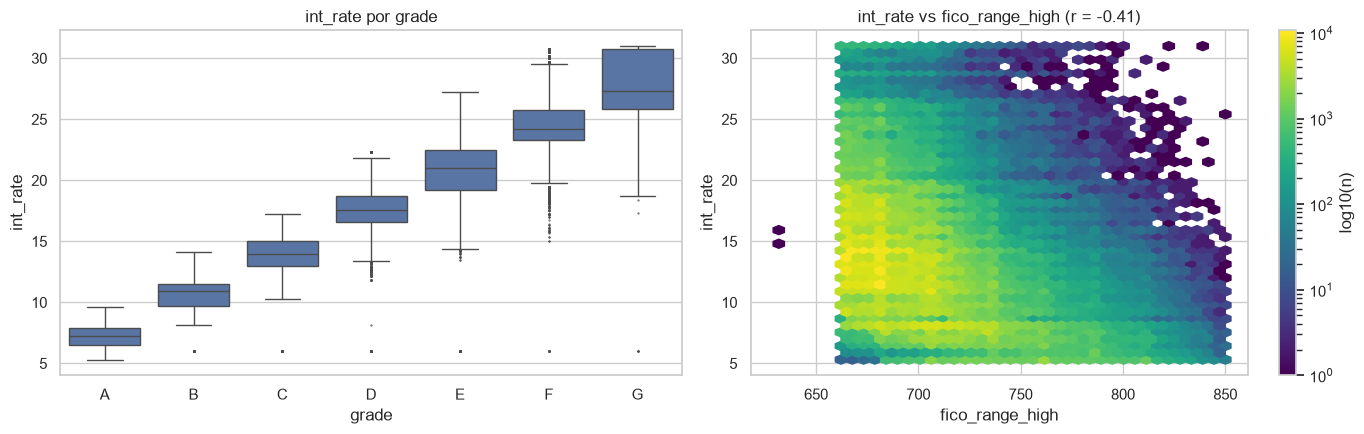

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=df, x="grade", y="int_rate", order=sorted(df["grade"].cat.categories), ax=axes[0],
            color="#4C72B0", fliersize=0.5)
axes[0].set_title("int_rate por grade")
hb = axes[1].hexbin(df["fico_range_high"], df["int_rate"], gridsize=40, bins="log", cmap="viridis", mincnt=1)
fig.colorbar(hb, ax=axes[1], label="log10(n)")
axes[1].set_xlabel("fico_range_high")
axes[1].set_ylabel("int_rate")
axes[1].set_title(f"int_rate vs fico_range_high (r = {corr.loc['int_rate', 'fico_range_high']:.2f})")
plt.tight_layout()
plt.show()

El diagrama de caja muestra la escalera de tasas por grado, con rangos que apenas se solapan entre grados adyacentes. El diagrama hexagonal evidencia la relación negativa entre FICO e `int_rate` ($r = -0{,}41$): los puntajes altos obtienen tasas bajas, aunque con una dispersión considerable para un mismo puntaje. Esa dispersión indica que la tasa incorpora información adicional al FICO, como el plazo, el endeudamiento o el historial, y por ello ambas variables se conservan.

### 1.3.4 Visualizaciones avanzadas

**Pairplot o matriz de dispersión** de las cinco variables numéricas más asociadas con `default`, coloreado por clase. Se dibuja sobre una **submuestra aleatoria estratificada de 20 000 préstamos**, solo para que el gráfico sea legible (el enunciado permite submuestrear en este caso). La submuestra no interviene en ningún cálculo.

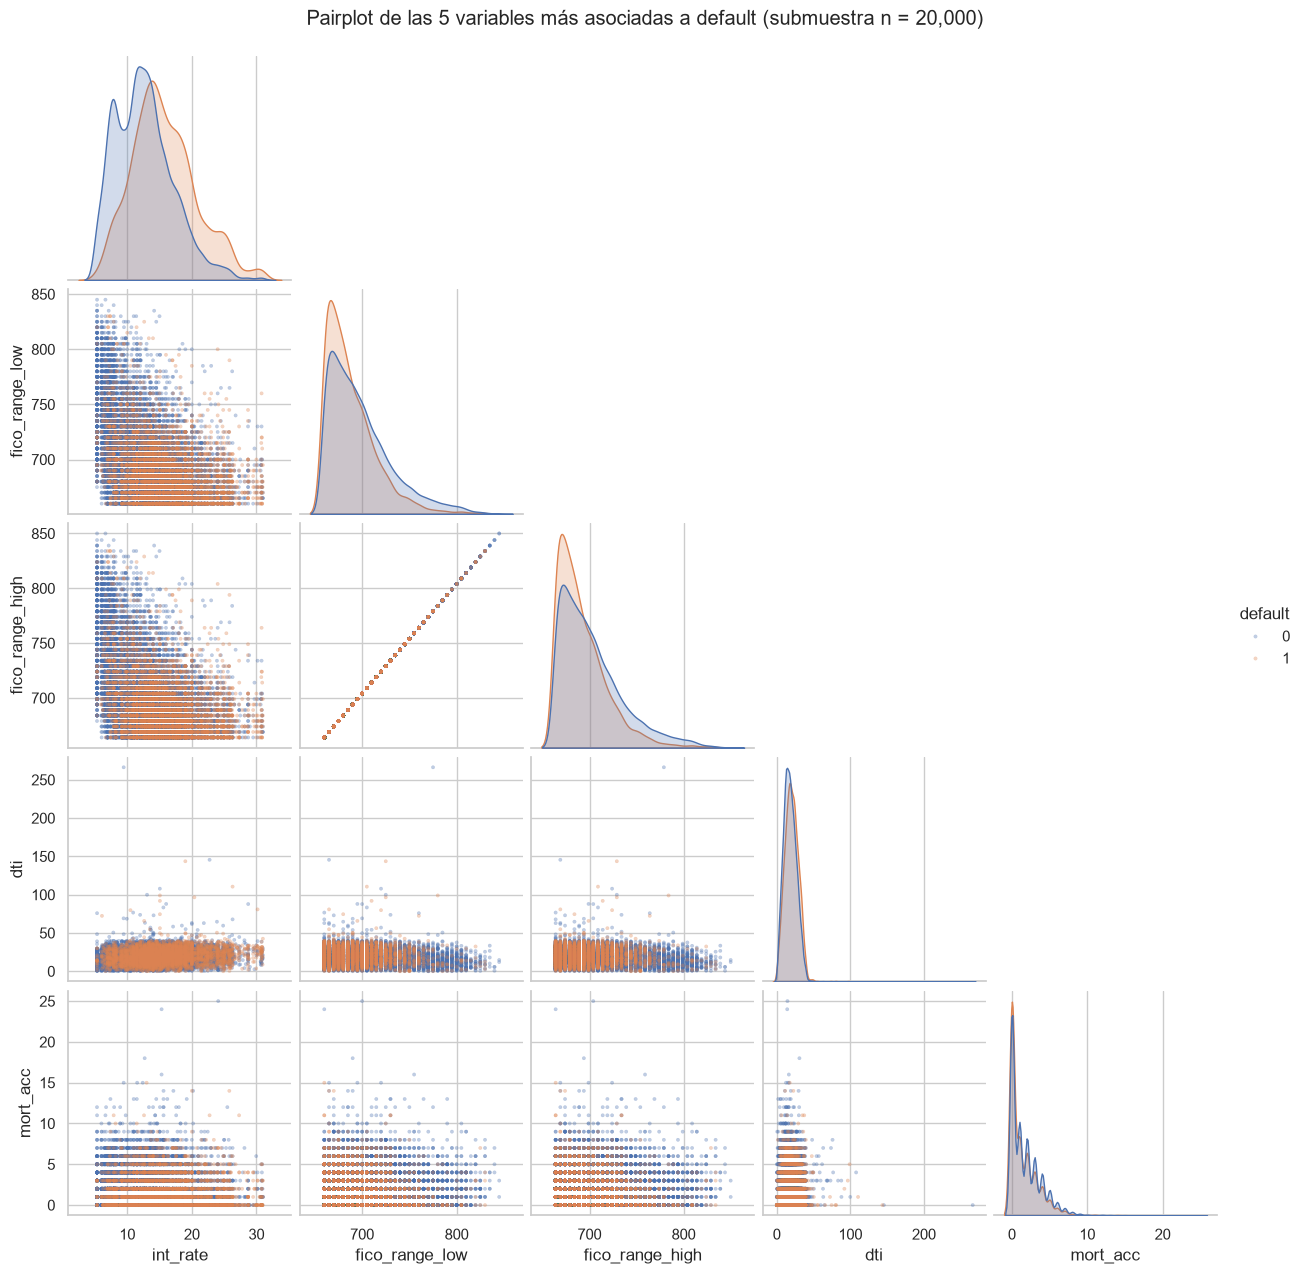

In [35]:
top5 = biv_num.index[:5].tolist()
sample = df.groupby(U.TARGET, group_keys=False).apply(
    lambda g: g.sample(frac=20_000 / len(df), random_state=U.SEED))
g = sns.pairplot(sample[top5 + [U.TARGET]], hue=U.TARGET, palette=PALETTE, corner=True,
                 plot_kws={"s": 6, "alpha": 0.35, "edgecolor": None}, diag_kws={"common_norm": False})
g.figure.suptitle(f"Pairplot de las 5 variables más asociadas a default (submuestra n = {len(sample):,})", y=1.02)
plt.show()

El *pairplot* confirma visualmente las relaciones descritas. La distribución marginal de `int_rate` en los préstamos en default está desplazada hacia la derecha, y la relación entre `fico_range_low` y `fico_range_high` es una recta perfecta. En los diagramas de dispersión, las dos clases se superponen extensamente, sin fronteras lineales ni no lineales evidentes en ningún par de variables. Se aprecian también la discretización de `fico_range` en saltos de cinco puntos y algunos valores de `dti` superiores a 100, casos aislados que motivan el recorte aplicado en el preprocesamiento.

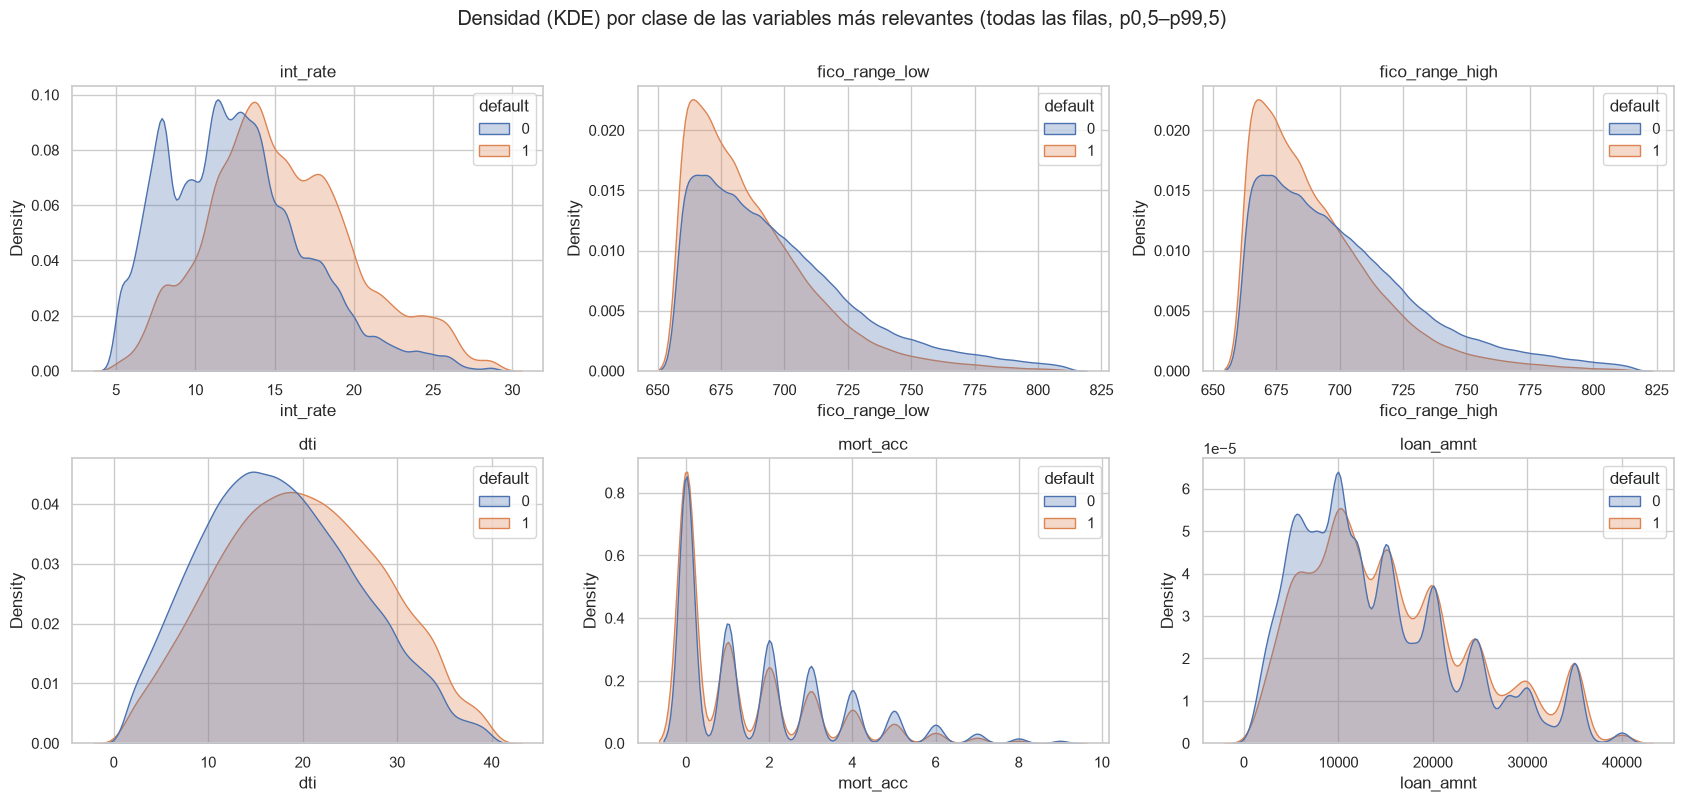

In [36]:
kde_vars = biv_num.index[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, c in zip(axes.flat, kde_vars):
    lo, hi = df[c].quantile([0.005, 0.995])
    sub = df.loc[df[c].between(lo, hi), [c, U.TARGET]]
    sns.kdeplot(data=sub, x=c, hue=U.TARGET, palette=PALETTE, common_norm=False, fill=True, alpha=0.3,
                ax=ax, bw_adjust=1.5, warn_singular=False)
    ax.set_title(c)
fig.suptitle("Densidad (KDE) por clase de las variables más relevantes (todas las filas, p0,5–p99,5)", y=1.0)
plt.tight_layout()
plt.show()

Las densidades por clase, estimadas con todas las observaciones, muestran que el desplazamiento de `int_rate` es el más marcado: los préstamos pagados tienen una moda cercana al 7 %, correspondiente al grado A, mientras que los defaults se concentran en torno al 14 % y exhiben una cola derecha mucho más pesada. En `fico_range`, los defaults acumulan su masa entre 660 y 690 puntos; en `dti` su densidad aparece desplazada unos tres puntos hacia valores mayores, y en `loan_amnt` y `mort_acc` las diferencias son perceptibles pero pequeñas, en coherencia con las correlaciones de la sección 1.3.1.

## 1.4 Valores faltantes

In [37]:
miss = pd.DataFrame({"n nulos": df[U.NUM_COLS + U.CAT_COLS].isna().sum()})
miss["% nulos"] = 100 * miss["n nulos"] / len(df)
miss = miss[miss["n nulos"] > 0].sort_values("% nulos", ascending=False)
miss

,n nulos,% nulos
mths_since_last_delinq,678743,50.453
emp_length,78511,5.836
mort_acc,47281,3.515
revol_util,857,0.064
pub_rec_bankruptcies,697,0.052
dti,374,0.028
inq_last_6mths,1,0.000


Solo siete de las variables analizadas tienen valores faltantes. `mths_since_last_delinq` (50,5 %) supera el umbral del 30 % y, como se discute más adelante, su ausencia es estructural. `emp_length` (5,8 %) y `mort_acc` (3,5 %) presentan tasas moderadas, y las cuatro variables restantes afectan a menos del 0,1 % de los préstamos, de modo que su tratamiento apenas influye en los resultados.

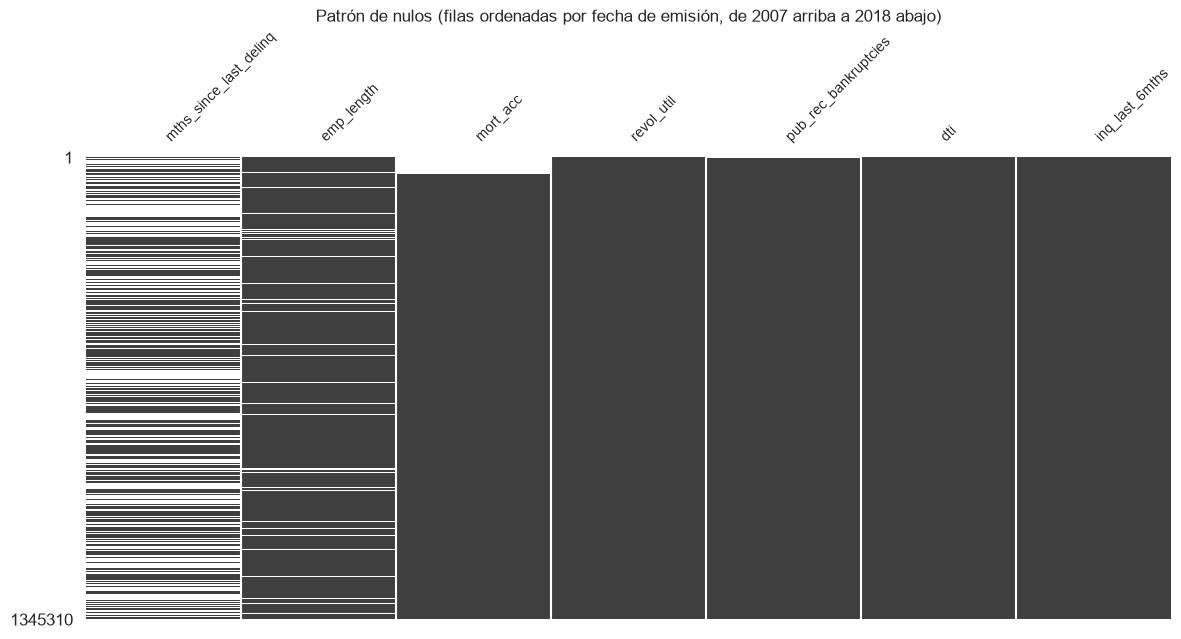

In [38]:
miss_cols = miss.index.tolist()
ordered = df.sort_values("issue_d")[miss_cols]
msno.matrix(ordered, figsize=(14, 6), fontsize=10, sparkline=False)
plt.title("Patrón de nulos (filas ordenadas por fecha de emisión, de 2007 arriba a 2018 abajo)")
plt.show()

La matriz de nulidad, con las filas ordenadas por fecha de emisión, revela que los faltantes no se distribuyen al azar a lo largo del tiempo. `mort_acc` falta en un bloque compacto al comienzo del periodo, correspondiente a los primeros años de la plataforma, mientras que `mths_since_last_delinq` y `emp_length` presentan faltantes dispersos en todo el horizonte.

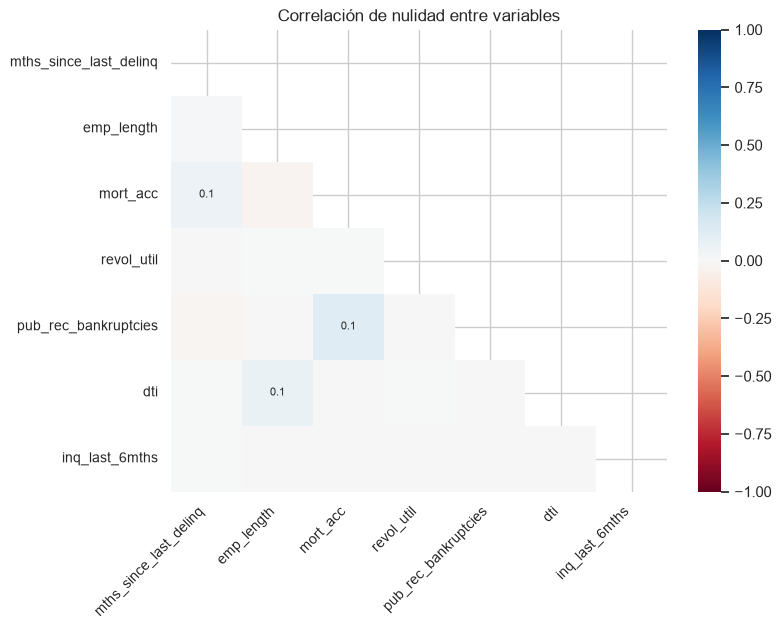

In [39]:
msno.heatmap(df[miss_cols], figsize=(8, 6), fontsize=10)
plt.title("Correlación de nulidad entre variables")
plt.show()

La correlación de nulidad entre pares de variables es prácticamente nula, con valores absolutos de 0,1 como máximo: la ausencia de un dato no predice la ausencia de otro. Los faltantes obedecen, por tanto, a mecanismos independientes en cada variable y pueden tratarse de forma individual.

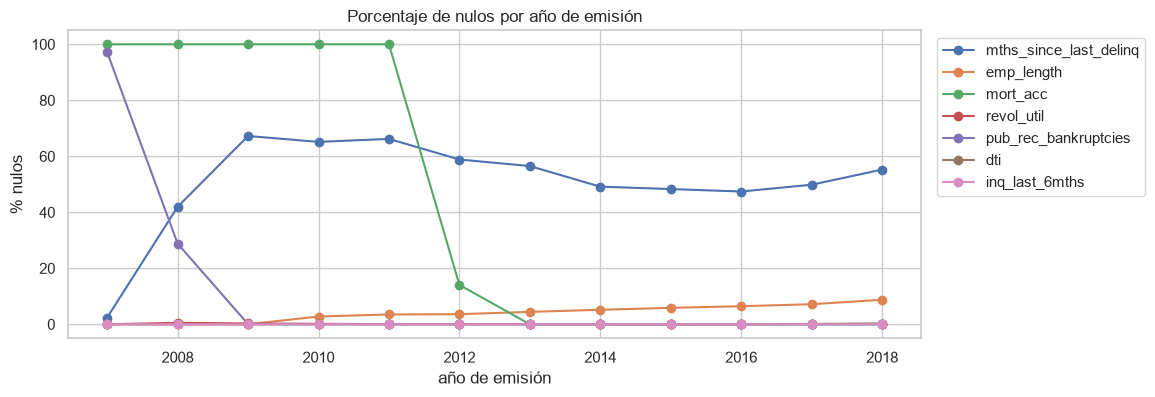

In [40]:
by_year_miss = df[miss_cols].isna().groupby(df["issue_d"].dt.year).mean().mul(100)
fig, ax = plt.subplots(figsize=(11, 4))
by_year_miss.plot(ax=ax, marker="o")
ax.set_ylabel("% nulos")
ax.set_xlabel("año de emisión")
ax.set_title("Porcentaje de nulos por año de emisión")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.show()

La evolución anual precisa esos mecanismos. `mort_acc` falta en el 100 % de los préstamos de 2007 a 2011 y en el 14 % de los de 2012, y `pub_rec_bankruptcies` en los de 2007 y buena parte de 2008: son campos que la plataforma comenzó a registrar más tarde. La proporción de nulos de `emp_length` crece gradualmente desde cerca de cero hasta el 8,6 %, y la de `mths_since_last_delinq` oscila entre el 45 % y el 67 %, según la proporción de solicitantes sin antecedentes de mora en cada cohorte.

**¿Faltan los datos completamente al azar (MCAR)?** Bajo MCAR, que un valor falte no depende ni de las demás variables ni del target. Se hacen dos verificaciones:

1. **Relación con el target.** Se compara la tasa de default entre las filas con y sin nulo en cada variable, con una prueba chi-cuadrado.
2. **Relación con otras variables observadas.** El gráfico anterior ya muestra si la proporción de nulos cambia con el año de emisión.

La prueba global de Little (1988) no está disponible en las librerías del curso; con este $n$ las dos verificaciones anteriores bastan para descartar MCAR cuando hay dependencia.

In [41]:
rows = []
for c in miss_cols:
    isnull = df[c].isna()
    ct = pd.crosstab(isnull, df[U.TARGET])
    chi2, p, *_ = stats.chi2_contingency(ct)
    rows.append({"variable": c, "% nulos": isnull.mean() * 100,
                 "% default si nulo": df.loc[isnull, U.TARGET].mean() * 100,
                 "% default si observado": df.loc[~isnull, U.TARGET].mean() * 100,
                 "chi2": chi2, "p-value": p,
                 "V de Cramér (nulo vs año)": U.cramers_v(isnull, df["issue_d"].dt.year)})
mcar = pd.DataFrame(rows).set_index("variable")
with pd.option_context("display.float_format", lambda v: f"{v:,.4g}"):
    display(mcar)

,% nulos,% default si nulo,% default si observado,chi2,p-value,V de Cramér (nulo vs año)
variable,,,,,,
mths_since_last_delinq,50.45,19.26,20.68,420.3,2.084e-93,0.08582
emp_length,5.836,26.91,19.53,"2,521",0,0.05151
mort_acc,3.515,14.56,20.16,893.5,2.5e-196,0.9267
revol_util,0.0637,21,19.96,0.5181,0.4716,0.01213
pub_rec_bankruptcies,0.05181,16.93,19.96,3.827,0.05043,0.7253
dti,0.0278,18.98,19.96,0.1672,0.6826,0.03659
inq_last_6mths,7.433e-05,0,19.96,0,1,0


Los resultados descartan que los faltantes sean completamente aleatorios en las tres variables con más nulos. En `emp_length` la ausencia es informativa: la tasa de default sube de 19,5 % a 26,9 % cuando el dato falta, posiblemente porque corresponde a solicitantes sin empleo formal o con ingresos irregulares. En `mort_acc` la ausencia está determinada casi por completo por el año de emisión ($V = 0{,}93$), un mecanismo de tipo MAR, y su menor tasa de default (14,6 %) refleja el perfil de las cohortes tempranas. En `mths_since_last_delinq` el faltante es estructural, pues indica que el prestatario nunca estuvo en mora, y por ello se asocia a una tasa de default algo menor (19,3 % frente a 20,7 %). Las variables con menos del 0,1 % de nulos no muestran asociación significativa con el objetivo ($p > 0{,}05$), lo que es compatible con un mecanismo MCAR.

**Plan de tratamiento de faltantes**

Se usan los umbrales del enunciado: **más de 70 % de nulos → eliminar**; **más de 30 % → eliminar o tratamiento avanzado**. Por debajo se imputa con la mediana (numéricas, por su asimetría) o con la moda (categóricas). Si el nulo es informativo (no MCAR) se añade un indicador binario `<var>_missing`. Los imputadores se ajustan **solo con el conjunto de entrenamiento**.

In [42]:
def plan(c):
    p = miss.loc[c, "% nulos"]
    informative = mcar.loc[c, "p-value"] < 0.05 and abs(mcar.loc[c, "% default si nulo"] - mcar.loc[c, "% default si observado"]) > 1
    if p > 70:
        return "eliminar (>70 % nulos)"
    if p > 30:
        return "eliminar la variable (>30 % nulos); se evalúa un indicador de nulidad"
    base = "mediana" if c in U.NUM_COLS else "moda"
    return f"imputar {base}" + (" + indicador de nulidad" if informative else "")

miss_plan = miss.assign(tratamiento=[plan(c) for c in miss.index])
miss_plan

,n nulos,% nulos,tratamiento
mths_since_last_delinq,678743,50.453,eliminar la variable (>30 % nulos); se evalúa ...
emp_length,78511,5.836,imputar mediana + indicador de nulidad
mort_acc,47281,3.515,imputar mediana + indicador de nulidad
revol_util,857,0.064,imputar mediana
pub_rec_bankruptcies,697,0.052,imputar mediana
dti,374,0.028,imputar mediana
inq_last_6mths,1,0.000,imputar mediana


El plan resultante combina eliminación e imputación según el mecanismo identificado en cada caso. `mths_since_last_delinq` se elimina, pero su información principal se conserva mediante el indicador `has_delinq_history`. `emp_length` y `mort_acc` se imputan con la mediana y se acompañan de indicadores de nulidad, dado que su ausencia es informativa; el resto se imputa con la mediana, robusta frente a la asimetría descrita. Todas las medianas se estiman exclusivamente con el conjunto de entrenamiento (capítulo 2), para evitar cualquier fuga de información desde el conjunto de prueba.

## 1.5 Guardado del dataset de análisis

Se guarda en Parquet el dataset filtrado (id, fecha, target y variables analizadas), que el capítulo de preprocesamiento reutiliza en scikit-learn. PySpark volverá a leer el CSV original, como exige el enunciado.

In [43]:
df.to_parquet(U.EDA_PARQUET, index=False)
print(U.EDA_PARQUET, f"{U.EDA_PARQUET.stat().st_size / 1e6:.1f} MB")

C:\Users\User\Desktop\GEOLOGÍA\MAESTRÍA\Semestre 2\MachineLearning\jbook_ml202330\data\lc_eda.parquet 37.6 MB


## 1.6 Resumen ejecutivo del EDA

El análisis se realizó sobre la totalidad del archivo `accepted_2007_to_2018Q4.csv` (2.260.701 registros y 151 columnas), del que se retuvieron los 1.345.310 préstamos con desenlace conocido: 80,04 % pagados por completo y 19,96 % en default. Ambos entornos de trabajo leen exactamente las mismas filas, siempre que Spark interprete las comillas según la norma RFC 4180 (`escape='"'`). De las 151 columnas se descartaron 38 por constituir fuga de información (pagos, recuperaciones, último FICO o acuerdos de liquidación, todos posteriores a la originación), 7 identificadores o campos de texto libre y 34 variables con más del 30 % de nulos. El análisis se concentró en 29 variables disponibles al originar el préstamo, más dos derivadas: la antigüedad del historial crediticio y la antigüedad laboral en años.

En cuanto a la calidad de los datos, los principales problemas son las colas extremas de `annual_inc`, `dti`, `revol_bal` y `revol_util`, que incluyen valores implausibles (ingresos nulos o de 11 millones, `dti` de 999, utilización de 892 %), y tres patrones de valores faltantes con mecanismos distintos. En `mths_since_last_delinq` la ausencia es estructural, porque el nulo indica ausencia de mora previa. En `emp_length` es informativa, pues el default sube a 26,9 % cuando falta. En `mort_acc` depende del periodo, ya que el campo no se registró antes de 2012. Ninguna variable es normal, y trece presentan asimetría severa.

La capacidad predictiva se concentra en pocas variables. La tasa de interés es, con amplitud, el predictor más asociado al default ($r_{pb} = 0{,}26$; correlación biserial por rangos de 0,37), seguida del grado (V = 0,26), el plazo (V = 0,18; 32,4 % de default a 60 meses) y el puntaje FICO ($r_{pb} = -0{,}13$). La razón deuda/ingreso, el número de hipotecas, el monto, las consultas recientes y la utilización revolvente aportan efectos pequeños pero consistentes, y variables como el estado de residencia, el tipo de solicitud o el estado de listado inicial tienen una asociación prácticamente nula. La superposición de las distribuciones de ambas clases en todas las variables anticipa un problema de discriminación difícil, con un techo de desempeño modesto.

Se identificaron además redundancias fuertes (`fico_range_low` y `fico_range_high`, $r = 1{,}00$; `installment` y `loan_amnt`, $r = 0{,}95$; `grade` e `int_rate`, $\eta = 0{,}95$), un desbalance moderado de clases y un efecto temporal marcado, con cohortes recientes censuradas que sesgan a la baja su tasa de default observada.

Estas observaciones fijan las decisiones del preprocesamiento. Se modelan dieciséis variables numéricas (`loan_amnt`, `int_rate`, `annual_inc`, `dti`, `fico_range_high`, `emp_length`, `credit_hist_years`, `delinq_2yrs`, `inq_last_6mths`, `open_acc`, `pub_rec`, `revol_bal`, `revol_util`, `total_acc`, `mort_acc` y `pub_rec_bankruptcies`), tres indicadores (`has_delinq_history`, `emp_length_missing` y `mort_acc_missing`) y siete categóricas (`term`, `home_ownership`, `verification_status`, `purpose`, `addr_state`, `initial_list_status` y `application_type`). Se excluyen `fico_range_low`, `installment` y `grade` por redundancia, y `mths_since_last_delinq` e `issue_d` por las razones expuestas. Las categorías minoritarias de `home_ownership` y `purpose` se agrupan; `dti` y `revol_util` se recortan a los percentiles 0,1 y 99,9; `annual_inc` y `revol_bal` se transforman con `log1p`; los faltantes se imputan con la mediana, y las variables numéricas se estandarizan. Todos los parámetros se estiman únicamente con el conjunto de entrenamiento. El desbalance se aborda con partición y validación cruzada estratificadas, selección por ROC AUC, reporte de AUC-PR y un umbral de decisión fijado con datos de entrenamiento, sin remuestreo, para preservar la comparabilidad entre scikit-learn y PySpark.